## Forward solver for Opinion Dynamics

In [1]:
import numpy as np
import matplotlib.pyplot as plt



# Newton solver for preimages
def newton_inverse(x, y, gamma, P, dP, Phi, xmin, xmax, u0=None, tol=1e-12, maxiter=10):

    if u0 is None:
        u = x
    else:
        u = u0

    for i in range(maxiter):

        F = u - gamma * P(u) * (u - Phi(y)) - x          
        dF = 1 - gamma * (P(u) + dP(u) * (u - Phi(y)))

        # bisection fallback if derivative is too small
        if abs(dF) < 1e-8 or i == maxiter-1:
            a, b = xmin, xmax
            Fa = a - gamma * P(a) * (a - Phi(y)) - x
            Fb = b - gamma * P(b) * (b - Phi(y)) - x
            if Fa * Fb > 0:
                return u   # fallback to last Newton iterate 
                
            for j in range(20):
                c = 0.5*(a+b)
                Fc = c - gamma * P(c) * (c - Phi(y)) - x

                if abs(Fc) < tol:
                    return c

                if Fa * Fc < 0:
                    b = c
                else:
                    a = c
                    Fa = Fc

            return 0.5*(a+b)

        unew = u - F/dF

        if abs(unew - u) < tol:
            return unew

        u = unew

    return u


#compute norm of kernel
def kernel_norm(theta,xgrid):
    N = len(xgrid)
    middle = xgrid[int(N/2)]
    norm = np.trapz(theta(middle,xgrid), xgrid)
    return norm


    
# precomputes array of preimages
def prime_x(xgrid, gamma, P, dP, Phi):
    N = len(xgrid)
    A = np.empty((N,N))

    Pvals = P(xgrid)
    if np.allclose(Pvals, Pvals[0]):
        c = Pvals[0]
        denom = 1.0 - gamma * c
        if abs(denom) < 1e-14:
            raise ValueError("1 - gamma*c is too small for explicit inverse.")
        for i in range(N):
            for j in range(N):
                A[i,j] = (xgrid[i] - gamma * c * Phi(xgrid[j])) / denom
    else:
        for i in range(N):
            guess = xgrid[i]
            for j in range(N):
                A[i,j] = newton_inverse(xgrid[i], xgrid[j], gamma, P, dP, Phi, xgrid[0], xgrid[-1], u0=guess)
                guess = A[i,j]
    return A


# integrate over domain (right hand side),  returns vector of lenght N
def rhs(f, xgrid, gamma, P, dP, Phi, theta, primex):

    N = len(xgrid)
    xmin = xgrid[0]
    xmax = xgrid[-1]
    dx = xgrid[1] - xgrid[0]
    
    df = np.zeros_like(f)
    y = xgrid
    
    
    for i in range(N):

        xi = xgrid[i]

        # loss term
        theta_vals = theta(xi, Phi(y))+theta(Phi(xi), y)
        loss = np.sum(theta_vals * f[i] * f * dx)

        # check for valid preimages
        mask = (primex[i,:] >= xmin) & (primex[i,:] <= xmax)  #keeps true and false

        primex_valid = primex[i,:][mask]                      #keeps the values just for true
        y_valid = xgrid[mask]
        f_valid = f[mask]

        # gain term
        fxp = np.interp(primex_valid, xgrid, f)

        #theta_vals = theta(primex_valid, y_valid)
        theta_vals = theta(Phi(primex_valid), y_valid)+ theta(primex_valid, Phi(y_valid))

        J = np.abs(1 - gamma * (P(primex_valid) + dP(primex_valid) * (primex_valid - Phi(y_valid))))

        gain = np.sum(theta_vals * fxp * f_valid * dx / J)

        # sum gain and loss term
        df[i] = (gain - loss)

    return df


# Runge-Kutta method to integrate over t
def rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, primex):
    k1= rhs(f, xgrid, gamma, P, dP, Phi, theta, primex)
    k2 = rhs(f + 0.5 * dt * k1, xgrid, gamma, P, dP, Phi, theta, primex)
    k3 = rhs(f + 0.5 * dt * k2, xgrid, gamma, P, dP, Phi, theta, primex)
    k4 = rhs(f + dt * k3, xgrid, gamma, P, dP, Phi, theta, primex)
    fnew = f + dt * (k1 + 2*k2 + 2*k3 + k4) / 6.0
    fnew = np.maximum(fnew, 0)
    mass = np.trapz(fnew, xgrid)
    if mass <= 1e-12 or not np.isfinite(mass):
        return f.copy()

    return fnew / mass

def cumulative_data(f, xgrid, a):
    ##Computes M(a,t) = integral_{xmin}^{a} f(x,t) dx (2.2)
    xmin = xgrid[0]
    xmax = xgrid[-1]

    if a <= xmin:
        return 0.0
    if a >= xmax:
        return np.trapz(f, xgrid)

    fa = np.interp(a, xgrid, f)

    mask = xgrid < a
    xpart = np.concatenate([xgrid[mask], [a]]) #in case a is not exactly on the grid it calculates a as well
    fpart = np.concatenate([f[mask], [fa]])

    return np.trapz(fpart, xpart)


def interval_data(f, xgrid, a, b):
    #Computes integral_a^b f(x,t) dx
    if b < a:
        a, b = b, a
    return cumulative_data(f, xgrid, b) - cumulative_data(f, xgrid, a)



## General Case

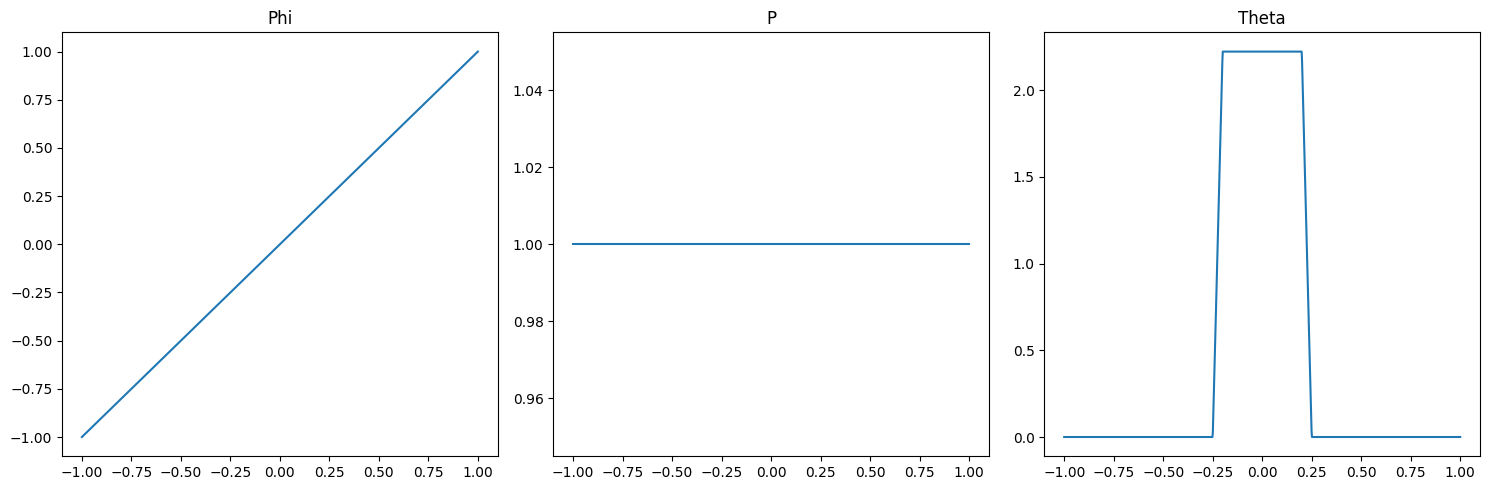

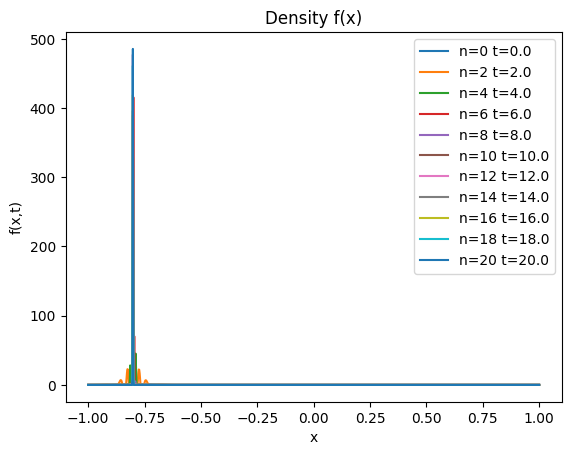

In [2]:

#-------------Numerical Parameters-------------
N = 1000  #grid size
xgrid = np.linspace(-1.0, 1.0, N)

dt = 1 #time step
T = 20  #stop time
steps = int(T / dt)


# -------Choices for Phi-------

def Phi_0(y):    #identity
    a=1
    return a*y   


def Phi_1(y):   #step function
    c = 0
    return -(y < c).astype(float)+(y > c).astype(float)    


def Phi_2(y):   #continuous 'step function'
    r=0.2
    return -(y < -r).astype(float)+(y > r).astype(float) + ((r > y)& (y > -r)).astype(float)*y/r

    
def Phi_3(y):     #variable S-curve, a=1: identity, a=0: y**3
    a=0.99 # for 0<=a<=1
    return a*(y)+(1-a)*y**3


def Phi_4(y):    # Quantization - problematic!!
    n=4
    return np.round(n*y)/n


def Phi_5(y):     #tanh
    return np.tanh(2*y)


#choose one function Phi
Phi = Phi_0


#-----------Choices for kernel Theta-----------------

def theta_0(x, y):     #bounded confidence - can be unstable! 
    r = 0.1
    d = np.abs(x - y)
    return (d <= r).astype(float)      

def theta_1(x,y):    #continuous bounded confidence - more stable
    r=0.2
    s=0.05     #widht of slanted sides
    d = np.abs(x - y)
    center = (d <= r).astype(float) 
    slope = ((d < r+s)&(d > r)).astype(float) * (-d/s + (r+s)/s)
    return center+slope    

def theta_2(x,y):   #Gaussian kernel
    sigma = 0.2
    return np.exp(-((x - y)**2) / (2 * sigma**2))    

def theta_3(x, y):   #Power Law kernel
    alpha = 0.5 
    eps = 1e-3
    return (np.abs(x - y) + eps) ** (-alpha)

#choose one kernel Theta
theta = theta_1


norm = kernel_norm(theta,xgrid)
theta_normed = lambda x,y: theta(x,y)/norm   #normalize kernel


#------------Function P----------------
def P(x):
    return np.ones_like(x)

def dP(x):
    return np.zeros_like(x)

    
gamma = 0.5


#--------Initial Distribution---------
f = 0*xgrid+1
#f = np.exp(- 1* (xgrid)**2)
#f = f / np.trapz(f, xgrid)          #normalizing the (integral of f =1)
f = np.exp(-((xgrid + 0.80) ** 2) / (2.0 * 0.06 ** 2))
#(-0.80, 0.06),(-0.60, 0.10), (-0.35, 0.08)(for mu or sigma)

#---------Computation---------

#plot Phi P and Theta
fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].plot(xgrid, Phi(xgrid))
axs[0].set_title('Phi')
axs[1].plot(xgrid, P(xgrid))
axs[1].set_title('P')
axs[2].plot(xgrid, theta_normed(0,xgrid))
axs[2].set_title('Theta')
plt.tight_layout()
plt.show()

#Array of preimage coordinates
A = prime_x(xgrid, gamma, P, dP, Phi) 

#iterate solver
snapshots = [f.copy()]
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta_normed, A)
    snapshots.append(f.copy())



#plot density f
n_plots=10   

for k, s in enumerate(snapshots):
    if k % max(1,int(steps/n_plots)) == 0:
        plt.plot(xgrid, s, label=f"n={k} t={k*dt:.1f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.title('Density f(x)')
plt.legend()
#plt.ylim(0,2)
plt.show()

## Checking the number of spikes 

In [35]:
from matplotlib.colors import ListedColormap, BoundaryNorm

# ---------- helper: Phi_a ----------
def make_phi_curve(a):
    def Phi(y):
        return a * y + (1 - a) * y**3
    return Phi

# ---------- helper: run forward problem ----------
def run_forward_problem(f_init, xgrid, dt, steps, gamma, P, dP, Phi, theta_used, A=None):
    f = f_init.copy()
    f = np.maximum(f, 0)
    f = f / np.trapezoid(f, xgrid)

    if A is None:
        A = prime_x(xgrid, gamma, P, dP, Phi)

    snapshots = [f.copy()]
    norms = []
    for _ in range(steps):
        f,norm = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta_used, A, True)
        snapshots.append(f.copy())
        if np.abs(norm-1)>0.05: break  # stop when numerics become unstable
    return snapshots

# ---------- helper: bounded-confidence kernel with radius r ----------
def make_theta_bc(radius):
    def theta(x, y):
        return (np.abs(x - y) <= radius).astype(float)
    return theta

# ---------- helper: simple smoothing ----------
def smooth_signal(f, window=9):
    if window <= 1:
        return f.copy()
    kernel = np.ones(window) / window
    return np.convolve(f, kernel, mode="same")

# ---------- helper: count spikes in final density ----------
def count_spikes(f, xgrid, smooth_window=9, min_height_ratio=0.15, min_distance_pts=25):

    fs = smooth_signal(f, window=smooth_window)

    # candidate local maxima
    candidates = []
    for i in range(1, len(fs) - 1):
        if fs[i] > fs[i - 1] and fs[i] >= fs[i + 1]:
            candidates.append(i)

    if len(candidates) == 0:
        return 0, fs, []

    # keep only peaks above height threshold
    max_val = np.max(fs)
    good = [i for i in candidates if fs[i] >= min_height_ratio * max_val]

    # enforce minimum distance, keeping taller peaks first
    good_sorted = sorted(good, key=lambda i: fs[i], reverse=True)
    selected = []

    for idx in good_sorted:
        if all(abs(idx - j) >= min_distance_pts for j in selected):
            selected.append(idx)

    selected = sorted(selected)
    return len(selected), fs, selected

In [36]:


# --- parameters ----------
N = 500
xgrid = np.linspace(-1.0, 1.0, N)

dt = 1.0
T = 20
steps = int(T / dt)

gamma = 0.5

def P(x):
    return np.ones_like(x)

def dP(x):
    return np.zeros_like(x)

# initial condition
f0 = 0 * xgrid + 1
f0 = f0 / np.trapezoid(f0, xgrid)

# ---------- scan parameters --------
r_values = np.linspace(0.2, 0.60, 21)       # x-axis
a_values = np.linspace(1.08, 0.92, 17)        # Phi_a(y)=a y + (1-a)y^3
delta_values = 1.0 - a_values# y-axis = deviation from identity


f_results = np.zeros((len(a_values), len(r_values), N))
phase = np.zeros((len(a_values), len(r_values)))
spike_counts = np.zeros((len(a_values), len(r_values)))
mean = np.zeros((len(a_values), len(r_values)))
var = np.zeros((len(a_values), len(r_values)))

# ---------- main scan ----------
for ia, a in enumerate(a_values):
    print(f"Running row {ia+1}/{len(a_values)}: a = {a:.4f}")
    Phi = make_phi_curve(a)

    # preimage array depends on Phi, so compute once per a
    A = prime_x(xgrid, gamma, P, dP, Phi)

    for ir, radius in enumerate(r_values):
        theta_raw = make_theta_bc(radius)
        norm = kernel_norm(theta_raw, xgrid)
        theta_used = lambda x, y, tr=theta_raw, n=norm: tr(x, y) / n

        snapshots = run_forward_problem(
            f0, xgrid, dt, steps, gamma, P, dP, Phi, theta_used, A=A
        )

        f_final = snapshots[-1]
        nspikes, _, _ = count_spikes(
            f_final,
            xgrid,
            smooth_window=9,
            min_height_ratio=0.15,
            min_distance_pts=25
        )
        f_results[ia, ir,:] = np.array(f_final)
        spike_counts[ia, ir] = nspikes
        mean[ia, ir] = np.trapezoid(xgrid * snapshots[-1], xgrid)
        var[ia, ir] = np.trapezoid(((xgrid - mean[ia, ir])**2) * snapshots[-1], xgrid)
        
        if np.median(snapshots[-1])>0.3: 
            phase[ia, ir] = np.nan # no sufficient convergence
            spike_counts[ia, ir] = np.nan
        elif nspikes <= 1:
            phase[ia, ir] = 0   # 1 spike phase
        elif nspikes == 2:
            phase[ia, ir] = 1   # 2 spike phase
        else:
            phase[ia, ir] = 2   # 3+ spike phase

# ---------- plots ----------
cmap = ListedColormap(["#2c7bb6", "#fdae61", "#d7191c"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

R, D = np.meshgrid(r_values, delta_values)

plt.figure(figsize=(8, 6))
plt.pcolormesh(R, D, phase, cmap=cmap, norm=norm, shading="auto")
cbar = plt.colorbar(ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["1 spike", "2 spikes", "3+ spikes"])

plt.xlabel("radius r")
plt.ylabel("deviation from identity = 1 - a")
plt.title(r"Phase diagram for $\Phi_a(y)=a y + (1-a)y^3$")
plt.show()

plt.figure(figsize=(8, 6))
plt.pcolormesh(R, D, spike_counts, shading="auto")
plt.colorbar(label="number of spikes")
plt.xlabel("radius r")
plt.ylabel("deviation from identity = 1 - a")
plt.title("Raw spike count")
plt.show()

AttributeError: module 'numpy' has no attribute 'trapezoid'

## Inverse Solver

In [3]:
# compute the input for inverse problem
def measure_density(f, xgrid, thresholds=None, intervals=None):
    thresholds = thresholds or []
    intervals = intervals or []

    data = {}

    for a in thresholds:
        data[("threshold", a)] = cumulative_data(f, xgrid, a)

    for (a, b) in intervals:
        data[("interval", a, b)] = interval_data(f, xgrid, a, b)

    return data

#Takes all time snapshots and converts them into a list of measurement records
def build_inverse_data(snapshots, xgrid, dt, thresholds=None, intervals=None):
    thresholds = thresholds or []
    intervals = intervals or []

    dataset = []

    for k, f in enumerate(snapshots):
        t = k * dt
        measurements = measure_density(f, xgrid, thresholds=thresholds, intervals=intervals)

        for key, value in measurements.items():
            dataset.append({
                "time_index": k,
                "time": t,
                "measurement": key,
                "value": value
            })

    return dataset

def run_forward_problem(f_init, xgrid, dt, steps, gamma, P, dP, Phi, theta_used, A=None):
    f = f_init.copy()
    f = np.maximum(f, 0)
    f = f / np.trapz(f, xgrid)

    if A is None:
        A = prime_x(xgrid, gamma, P, dP, Phi)

    snapshots = [f.copy()]
    for _ in range(steps):
        f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta_used, A)
        snapshots.append(f.copy())

    return snapshots


#make a vector of M(a,t) for a list of thresholds and time indices
def make_M_feature_vector(snapshots, xgrid, thresholds, time_indices=None):
    if time_indices is None:
        time_indices = range(len(snapshots))

    features = []
    for k in time_indices:
        f_snap = snapshots[k]
        for a in thresholds:
            features.append(cumulative_data(f_snap, xgrid, a))

    return np.array(features, dtype=np.float32)

#if we have multiple f-0
def make_multi_f0_feature_vector(snapshot_groups, xgrid, thresholds, time_indices=None):
    features = []
    for snapshots in snapshot_groups:
        vec = make_M_feature_vector(snapshots, xgrid, thresholds, time_indices=time_indices)
        features.extend(vec.tolist())
    return np.array(features, dtype=np.float32)

#next two will be used for generating Gaussian 
def normalize_density(f, xgrid):
    mass = np.trapz(f, xgrid)
    if mass <= 0:
        raise ValueError("Density has nonpositive mass.")
    return f / mass


def gaussian_density(xgrid, mu, sigma):
    f = np.exp(-((xgrid - mu) ** 2) / (2.0 * sigma ** 2))
    return normalize_density(f, xgrid)




## Gaussian Kernel - Stable and Unstable Steady States

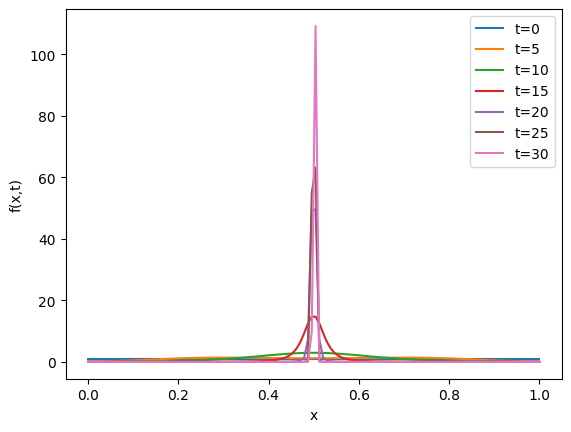

max at  0.5
t = 30.0 mass = 1.0000000000000002 min f = 2.8922768013642507e-06


In [29]:
def Phi(y):
  return y
    
def P(x):
    return 1

def dP(x):
    return 0

sigma = 0.2

def theta(x, y):
    return np.exp(-((x - y)**2) / (2 * sigma**2))

N = 120
xgrid = np.linspace(0.0, 1.0, N)

#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)          #normalizing the (integral of f =1)

dt = 0.1
T = 30
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]


A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 5 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.0f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()
print('max at ', np.argmax(f)/N)
print("t =", (n+1)*dt, "mass =", np.trapz(f, xgrid), "min f =", f.min())  #Just to check the min f is positive
#Gaussian kernel, p=1

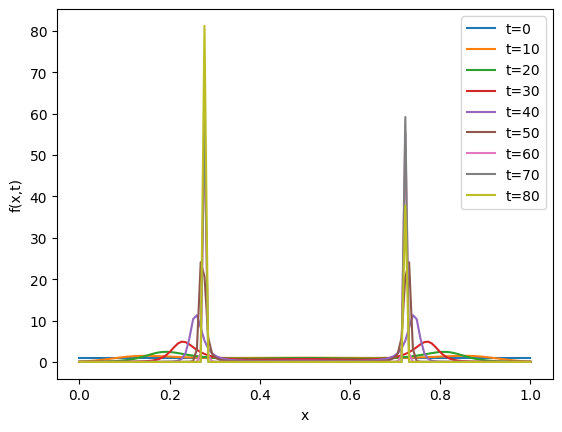

t = 80.0 mass = 0.9999999999999998 min f = 7.623997965711278e-10


In [30]:
def Phi(y):
  return y
def P(x):
    return 1

def dP(x):
    return 0

sigma = 0.1

def theta(x, y):
    return np.exp(-((x - y)**2) / (2 * sigma**2))

N = 120
xgrid = np.linspace(0.0, 1.0, N)

#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)          #normalizing the (integral of f =1)

dt = 0.1
T = 80
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]

A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k%10==0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.0f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

print("t =", (n+1)*dt, "mass =", np.trapz(f, xgrid), "min f =", f.min())  #Just to check the min f is positive
#Gaussian kernel, p=1, grid =121

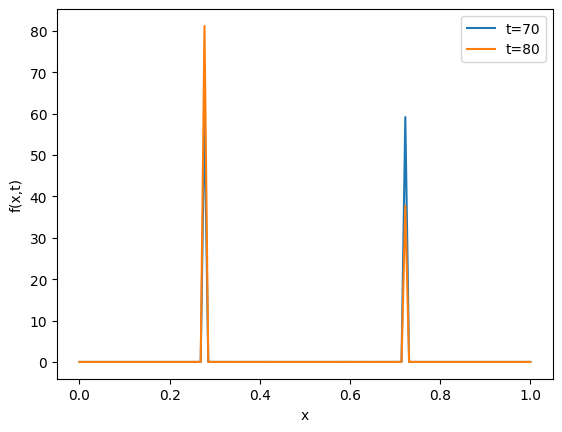

In [31]:
for k, s in enumerate(snapshots):
    if k==80 or k==70:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.0f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

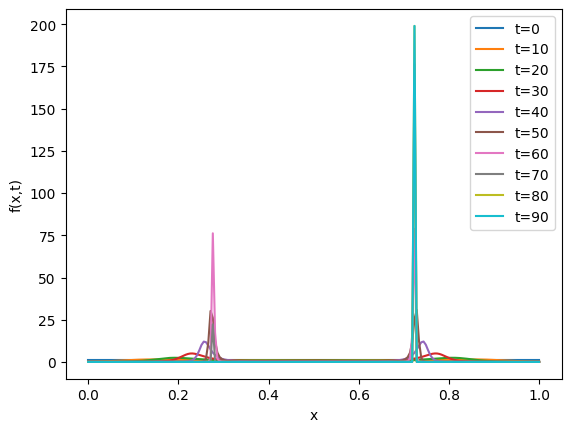

t = 90.0 mass = 0.9999999999999997 min f = 2.3077483449403582e-17


In [32]:
def Phi(y):
  return y
def P(x):
    return 1

def dP(x):
    return 0

sigma = 0.1

def theta(x, y):
    return np.exp(-((x - y)**2) / (2 * sigma**2))

N = 200
xgrid = np.linspace(0.0, 1.0, N)

#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)          #normalizing the (integral of f =1)

dt = 0.1
T = 90
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]

A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 10 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.0f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

print("t =", (n+1)*dt, "mass =", np.trapz(f, xgrid), "min f =", f.min())  #Just to check the min f is positive
#Gaussian kernel, p=1, changed the grids to 200

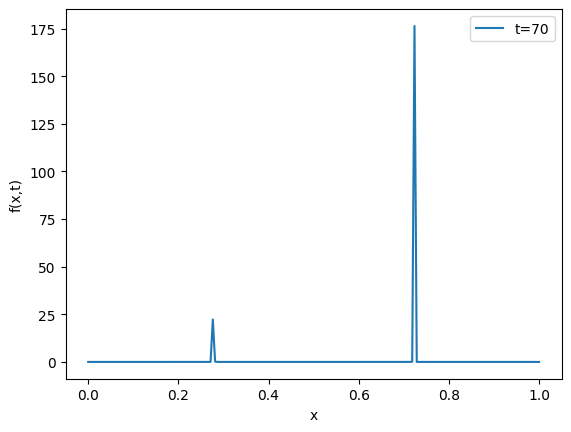

In [33]:
for k, s in enumerate(snapshots):
    if k == 70:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.0f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

## Power Law Kernel

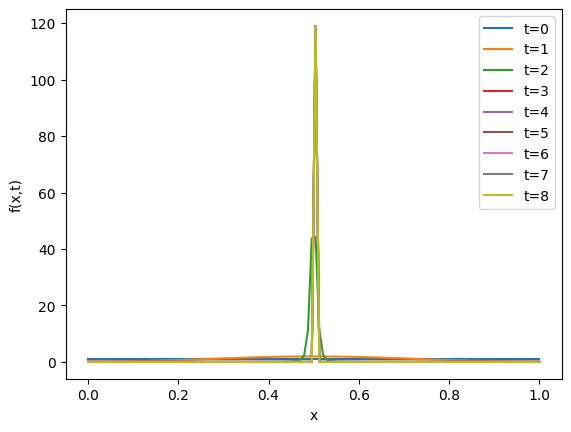

t = 8.0 mass = 1.0 min f = 0.0


In [34]:
def Phi(y):
  return y
    
def P(x):
    return 1

def dP(x):
    return 0

alpha = 0.5
eps = 1e-6

#def theta(x, y):
#    return (abs(x - y) + eps) ** (-alpha)   #when x=y it'll go to infinity so we add some noise!

def theta(x, y):
    raw = (np.abs(x - y) + eps) ** (-alpha)

    x = np.atleast_1d(x)          # make sure x is an array
    norm = np.array([np.trapz((np.abs(xi - xgrid) + eps) ** (-alpha), xgrid) for xi in x])

    return raw / norm


N = 120
xgrid = np.linspace(0.0, 1.0, N)

#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)          #normalizing the (integral of f =1)

dt = 0.1
T = 8
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]

A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    plt.plot(xgrid, s, label=f"t={k*10*dt:.0f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

print("t =", (n+1)*dt, "mass =", np.trapz(f, xgrid), "min f =", f.min())  #Just to check the min f is positive
#power law kernel, p=1, alpha=0.5

## Nonconstant P

### P=0.5 x

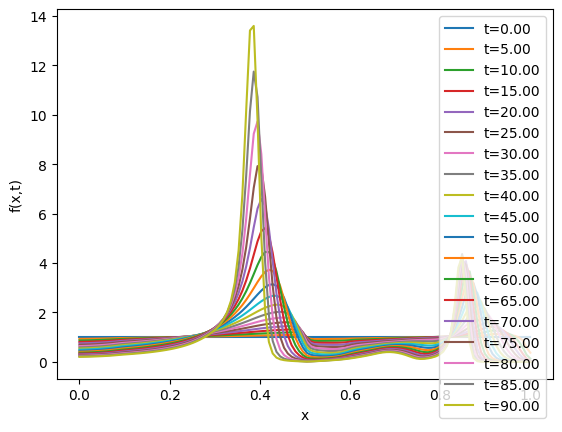

In [35]:
def Phi(y):
  return y
def P(x):
    return 0.5*x

def dP(x):
    return 0.5

def theta(x, y):
    return (np.abs(x - y) < 0.1).astype(float)

N = 120
xgrid = np.linspace(0.0, 1.0, N)

#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.1
T = 90
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]


A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates

for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 5 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")
plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

#when radius is 0.1, p=0.5*x

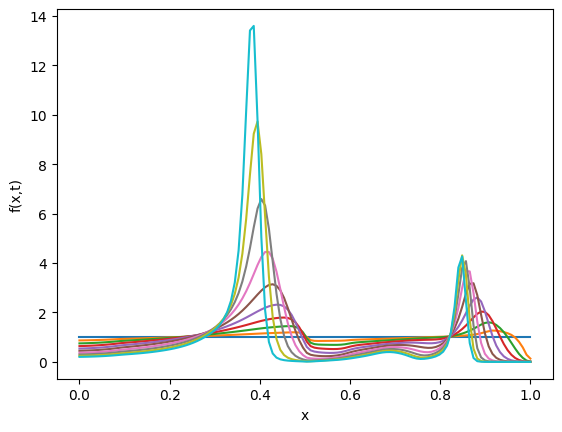

In [36]:
for k, s in enumerate(snapshots):
    if k % 10 ==0:
        plt.plot(xgrid, s)
plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.show()

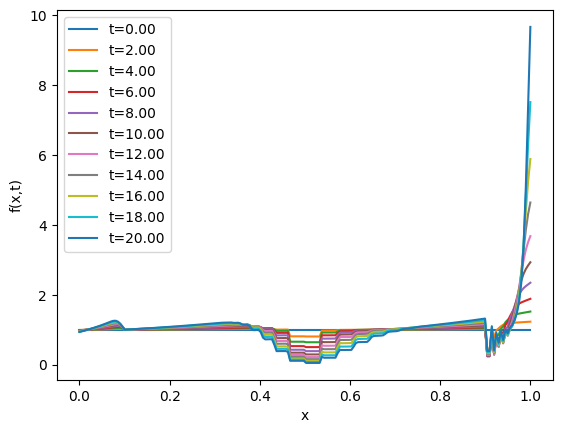

In [37]:
def Phi(y):
    return (np.abs(y) > 0.5).astype(float)

    
def P(x):
    return 0.5*x

def dP(x):
    return 0.5

def theta(x, y):
    return (np.abs(x - y) < 0.1).astype(float)

N = 200
xgrid = np.linspace(0.0, 1.0, N)

#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.1
T = 20
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]



A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 2 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")
plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

#when radius is 0.1, p=0.5*x, step function on 0.5

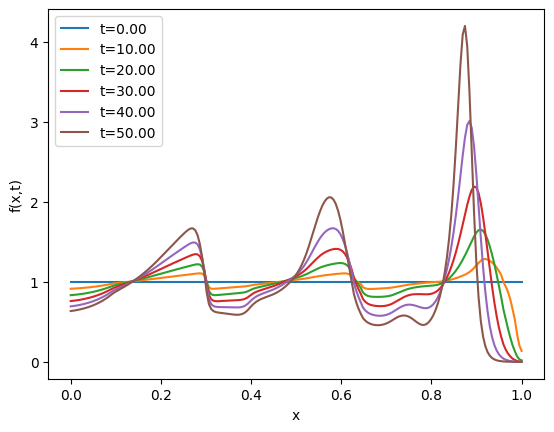

In [38]:
def Phi(y):
  return y
def P(x):
    return 0.5*x

def dP(x):
    return 0.5

def theta(x, y):
    return (np.abs(x - y) < 0.1).astype(float)

N = 200
xgrid = np.linspace(0.0, 1.0, N)

#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.1
T = 50
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]

A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 10 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")
plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

#when radius is 0.1, p=0.5*x

In [39]:
print("t =", (n+1)*dt, "mass =", np.trapz(f, xgrid), "min f =", f.min())  #Just to check the min f is positive

t = 50.0 mass = 0.9999999999999998 min f = 0.0006672932210882208


### P = 2x

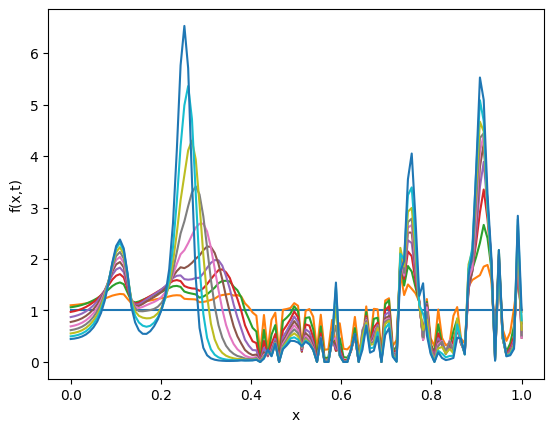

In [40]:
def Phi(y):
  return y
def P(x):
    return 2*x

def dP(x):
    return 2

def theta(x, y):
    return (np.abs(x - y) < 0.1).astype(float)

N = 120
xgrid = np.linspace(0.0, 1.0, N)

#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.1
T = 50
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]

A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 5 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")
plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.show()



# Invalid choice of P, not domain preserving! Bad behaviour at large x!

### P = x**2

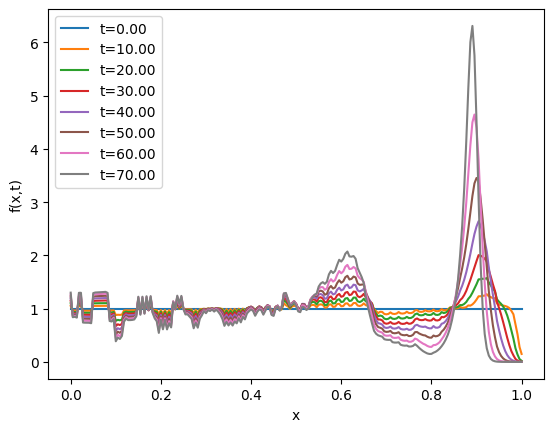

t = 70.0 mass = 1.0 min f = 2.2491581858114604e-06


In [41]:
def Phi(y):
  return y
def P(x):
    return x**2

def dP(x):
    return 2*x

def theta(x, y):
    return (np.abs(x - y) < 0.1).astype(float)

N = 221
xgrid = np.linspace(0.0, 1.0, N)
#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.05
T = 70
steps = int(T / dt)
gamma = 0.1
snapshots = [f.copy()]


A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 20 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")
plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()
print("t =", (n+1)*dt, "mass =", np.trapz(f, xgrid), "min f =", f.min())  #Just to check the min f is positive
#gamma=0.1, p=x^2  poor numerical behaviour, small derivative at 0?

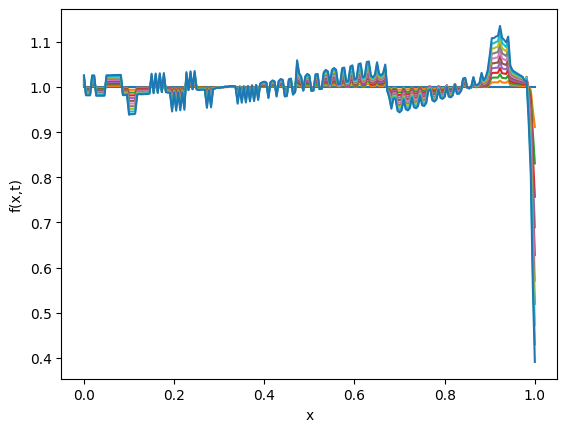

In [42]:
for k, s in enumerate(snapshots):
    if k < 11 :
        plt.plot(xgrid, s)
plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.show()

### P = 1-x**2

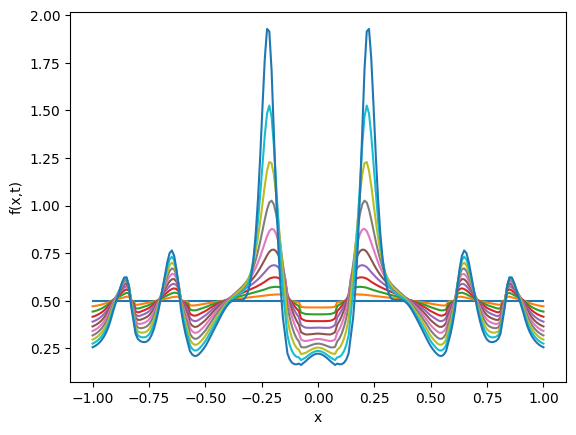

In [43]:
def Phi(y):
  return y
def P(x):
    return 1-x**2

def dP(x):
    return -2*x

def theta(x, y):
    return (np.abs(x - y) < 0.1).astype(float)

    
N = 200
xgrid = np.linspace(-1.0, 1.0, N)
#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.1
T = 50
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]


A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    f = f / np.trapz(f, xgrid)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 5 == 0:
        plt.plot(xgrid, s)

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.show()
#Toscani, when radius is 0.1, p=1-x^2 (Also changed the grid[-1,1])

### P = x(1-x)   -   Different Kernels

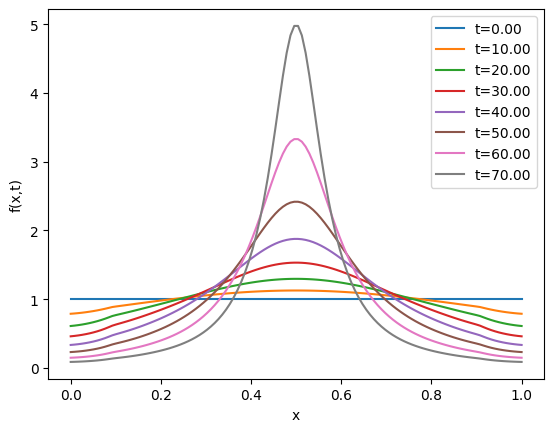

t = 70.0 mass = 1.0000000000000002 min f = 0.08939260212805475


In [44]:
def Phi(y):
  return y
def P(x):
    return x-x**2

def dP(x):
    return 1-2*x

def theta(x, y):
    return (np.abs(x - y) < 0.1).astype(float)

N = 120
xgrid = np.linspace(0.0, 1.0, N)
#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.1
T = 70
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]


A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 10 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

print("t =", (n+1)*dt, "mass =", np.trapz(f, xgrid), "min f =", f.min())  #Just to check the min f is positive
#when radius is 0.1, p=x(1-x)

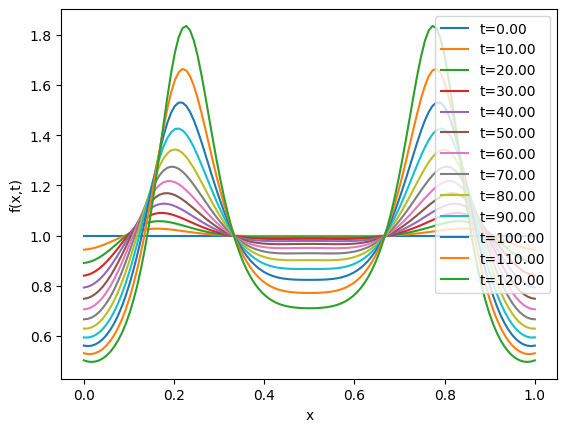

t = 120.0 mass = 0.9999999999999999 min f = 0.4961359470884843


In [45]:
def Phi(y):
  return y
def P(x):
    return x-x**2

def dP(x):
    return 1-2*x


sigma = 0.1

def theta(x, y):
    return np.exp(-((x - y)**2) / (2 * sigma**2))

N = 120
xgrid = np.linspace(0.0, 1.0, N)
#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.1
T = 120
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]


A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 10 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

print("t =", (n+1)*dt, "mass =", np.trapz(f, xgrid), "min f =", f.min())  #Just to check the min f is positive
#New Gaussian Kernel, p=x(1-x) #this is taking a while to converge, sigma=0.1

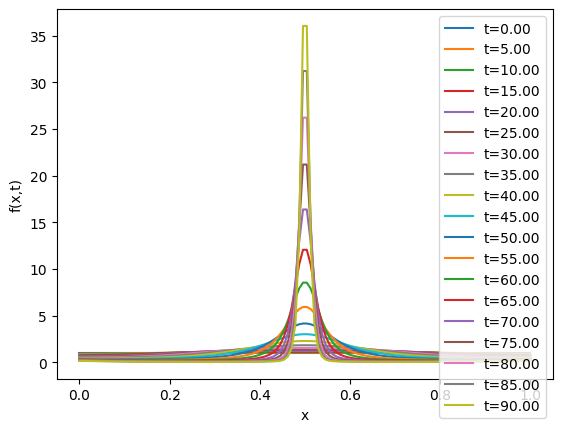

t = 90.0 mass = 1.0 min f = 0.03425743680994972


In [46]:
def Phi(y):
  return y
def P(x):
    return x-x**2

def dP(x):
    return 1-2*x


sigma = 0.2

def theta(x, y):
    return np.exp(-((x - y)**2) / (2 * sigma**2))

N = 120
xgrid = np.linspace(0.0, 1.0, N)
#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.1
T = 90
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]


A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 5 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

print("t =", (n+1)*dt, "mass =", np.trapz(f, xgrid), "min f =", f.min())  #Just to check the min f is positive
#New Gaussian Kernel, p=x(1-x), having bigger sigma=0.2

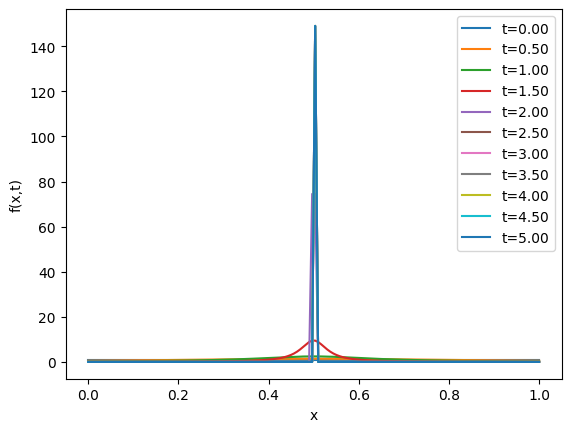

t = 5.0 mass = 1.0 min f = 0.0


In [47]:
def Phi(y):
  return y
def P(x):
    return x-x**2

def dP(x):
    return 1-2*x

alpha = 0.5
eps = 1e-6

def theta(x, y):
    return (abs(x - y) + eps) ** (-alpha)   #when x=y it'll go to infinity so we add some noise!


N = 150
xgrid = np.linspace(0.0, 1.0, N)
#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.05
T = 5
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]



A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 1 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

print("t =", (n+1)*dt, "mass =", np.trapz(f, xgrid), "min f =", f.min())  #Just to check the min f is positive
#Power law Kernel, p=x(1-x), alpha=0.5

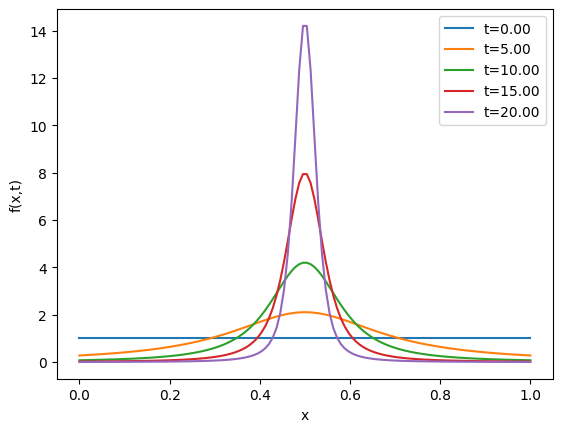

t = 20.0 mass = 1.0000000000000002 min f = 0.005484042378728208


In [48]:
def Phi(y):
  return y
def P(x):
    return x-x**2

def dP(x):
    return 1-2*x

alpha = 0.01
eps = 1e-6

def theta(x, y):
    return (abs(x - y) + eps) ** (-alpha)   #when x=y it'll go to infinity so we add some noise!


N = 120
xgrid = np.linspace(0.0, 1.0, N)
#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.1
T = 20
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]


A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 5 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

print("t =", (n+1)*dt, "mass =", np.trapz(f, xgrid), "min f =", f.min())  #Just to check the min f is positive
#Power law Kernel, p=x(1-x), alpha=0.01

### P = sqrt(x) sqrt(1-x)

/var/folders/x0/cmwf3yqn63j6y1wg5vy74syw0000gn/T/ipykernel_10292/1457724386.py:4: RuntimeWarning: invalid value encountered in scalar power
  return (x**0.5)*(1-x)**0.5
/var/folders/x0/cmwf3yqn63j6y1wg5vy74syw0000gn/T/ipykernel_10292/1457724386.py:8: RuntimeWarning: invalid value encountered in scalar power
  return 0.5*((x+eps)**(-0.5))*(1-x)**0.5 - (x**0.5)*(0.5 * ((1-x+eps)**(-0.5)))


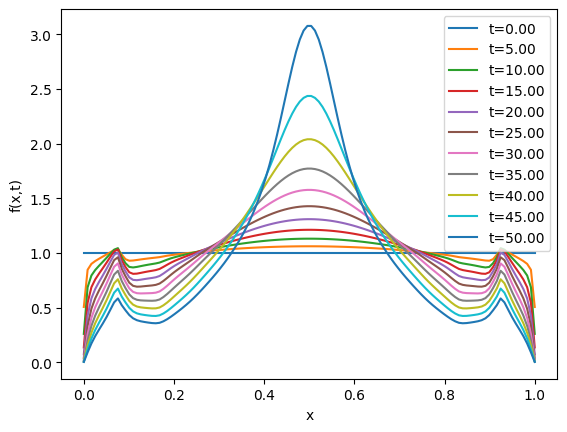

t = 50.0 mass = 0.9999999999999997 min f = 0.0032723114626342946


In [49]:
def Phi(y):
  return y
def P(x):
    return (x**0.5)*(1-x)**0.5

def dP(x):
    eps = 1e-5
    return 0.5*((x+eps)**(-0.5))*(1-x)**0.5 - (x**0.5)*(0.5 * ((1-x+eps)**(-0.5))) 

def theta(x, y):
    return (np.abs(x - y) < 0.1).astype(float)

N = 120
xgrid = np.linspace(0.0, 1.0, N)
#f = np.exp(-200 * (xgrid - 0.5)**2)
f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.1
T = 50
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]


A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 5 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

print("t =", (n+1)*dt, "mass =", np.trapz(f, xgrid), "min f =", f.min())  #Just to check the min f is positive
#when radius is 0.1,but we have p=x^0.5(1-x)^0.5

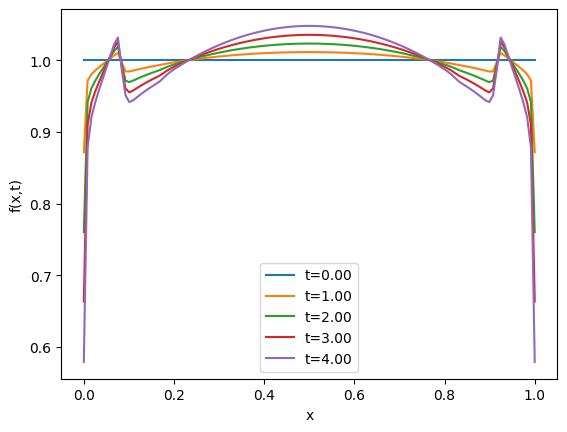

In [50]:
for k, s in enumerate(snapshots):
    if k< 5:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()

### Gaussian Initial Distribution - Different Kernels

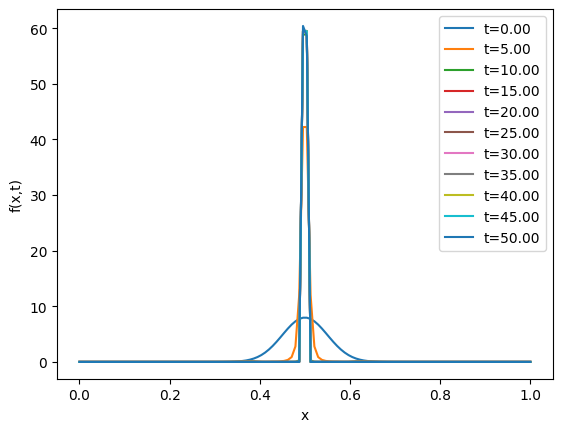

In [51]:
#from here we just have the exponential initial distribution

def Phi(y):
  return y
def P(x):
    return 1

def dP(x):
    return 0

def theta(x, y):
    return (np.abs(x - y) < 0.1).astype(float)


N = 120
xgrid = np.linspace(0.0, 1.0, N)
f = np.exp(-200 * (xgrid - 0.5)**2)
#f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.1
T = 50
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]


A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k%5 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()
#when radius is 0.1, p=1, exponential inital value

In [52]:
def Phi(y):
  return y
def P(x):
    return 2*x

def dP(x):
    return 2

def theta(x, y):
    return (np.abs(x - y) < 0.1).astype(float)


N = 120
xgrid = np.linspace(0.0, 1.0, N)
f = np.exp(-200 * (xgrid - 0.5)**2)
#f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.1
T = 30
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]

for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, theta)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 5 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()
#when radius is 0.1, p=2x
#around x=0.5 basically for both p=1 and p=2x we have p=1, but for x>0.5 p>1 so that's why the spike is a bit sharper than case p=1

TypeError: rk4_step() missing 2 required positional arguments: 'theta' and 'primex'

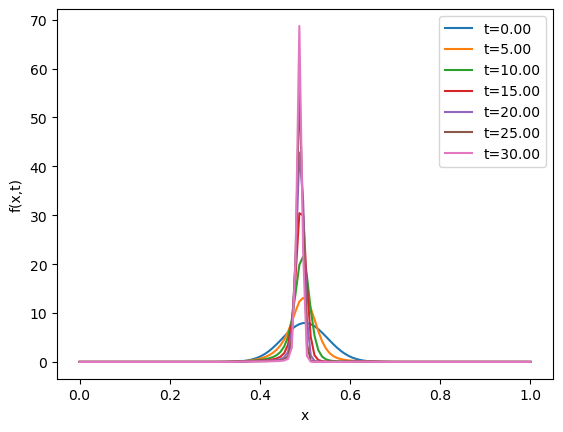

In [ ]:
def Phi(y):
  return y
def P(x):
    return x**2

def dP(x):
    return 2*x

def theta(x, y):
    return (np.abs(x - y) < 0.1).astype(float)

N = 120
xgrid = np.linspace(0.0, 1.0, N)
f = np.exp(-200 * (xgrid - 0.5)**2)
#f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.1
T = 30
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]


A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 5 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()
# p=x^2, Not symmetric
#in this case for x=0.5 p=0.25 and p in all the points is much smaller than cases p=1 and p=2x so smaller spikes

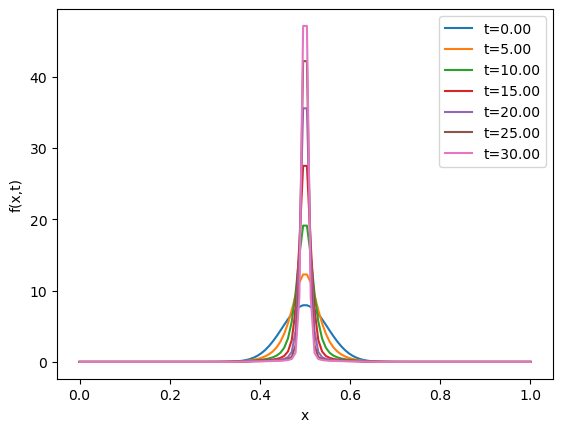

In [ ]:
def Phi(y):
  return y
def P(x):
    return x-x**2

def dP(x):
    return 1-2*x

def theta(x, y):
    return (np.abs(x - y) < 0.1).astype(float)


N = 120
xgrid = np.linspace(0.0, 1.0, N)
f = np.exp(-200 * (xgrid - 0.5)**2)
#f = 0*xgrid+1
f = f / np.trapz(f, xgrid)

dt = 0.1
T = 30
steps = int(T / dt)
gamma = 0.3
snapshots = [f.copy()]


A = prime_x(xgrid, gamma, P, dP, Phi) #Array of preimage coordinates
for n in range(steps):
    f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta, A)
    if (n + 1) % 10 == 0:
        snapshots.append(f.copy())

for k, s in enumerate(snapshots):
    if k % 5 == 0:
        plt.plot(xgrid, s, label=f"t={k*10*dt:.2f}")

plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.legend()
plt.show()
#when radius is 0.1, p=x(1-x), Symmetric

## Generating the Data for the inverse problem

In [6]:
thresholds = [-0.8, -0.6]
intervals = [(-1.0, -0.8), (-1.0, -0.6)]

dataset = build_inverse_data(
    snapshots,
    xgrid,
    dt,
    thresholds=thresholds,
    intervals=intervals
)

for item in dataset:
    print(item)

{'time_index': 0, 'time': 0, 'measurement': ('threshold', -0.8), 'value': 0.09999999999999998}
{'time_index': 0, 'time': 0, 'measurement': ('threshold', -0.6), 'value': 0.2}
{'time_index': 0, 'time': 0, 'measurement': ('interval', -1.0, -0.8), 'value': 0.09999999999999998}
{'time_index': 0, 'time': 0, 'measurement': ('interval', -1.0, -0.6), 'value': 0.2}
{'time_index': 1, 'time': 1, 'measurement': ('threshold', -0.8), 'value': 0.08053864340099176}
{'time_index': 1, 'time': 1, 'measurement': ('threshold', -0.6), 'value': 0.1953846079896699}
{'time_index': 1, 'time': 1, 'measurement': ('interval', -1.0, -0.8), 'value': 0.08053864340099176}
{'time_index': 1, 'time': 1, 'measurement': ('interval', -1.0, -0.6), 'value': 0.1953846079896699}
{'time_index': 2, 'time': 2, 'measurement': ('threshold', -0.8), 'value': 0.06145237460143595}
{'time_index': 2, 'time': 2, 'measurement': ('threshold', -0.6), 'value': 0.18618256788196258}
{'time_index': 2, 'time': 2, 'measurement': ('interval', -1.0, -

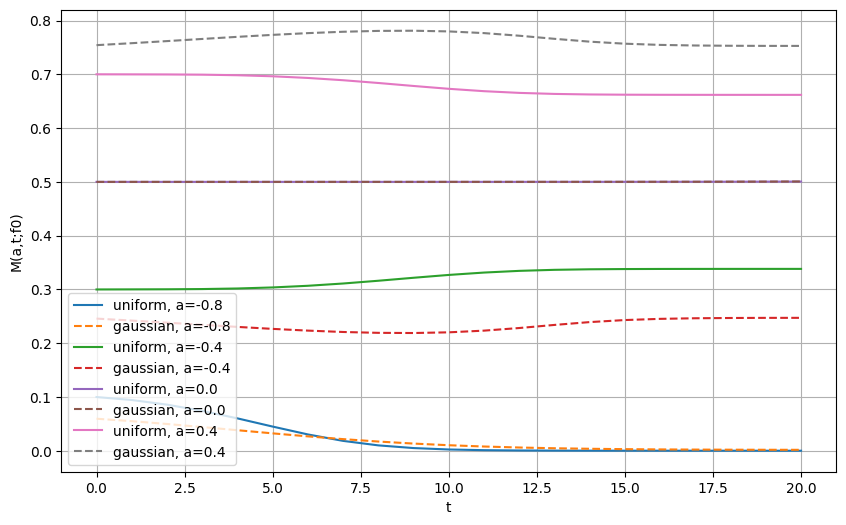

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# run forward problem for a given initial f0

def run_forward_problem(f_init, xgrid, dt, steps, gamma, P, dP, Phi, theta_normed):
    f = f_init.copy()
    f = np.maximum(f, 0)
    f = f / np.trapz(f, xgrid)

    A = prime_x(xgrid, gamma, P, dP, Phi)

    snapshots = [f.copy()]
    for n in range(steps):
        f = rk4_step(f, dt, xgrid, gamma, P, dP, Phi, theta_normed, A)
        snapshots.append(f.copy())

    return snapshots


f0_uniform = 0 * xgrid + 1
f0_gaussian = np.exp(-(xgrid**2))

# run both
snapshots_uniform = run_forward_problem(
    f0_uniform, xgrid, dt, steps, gamma, P, dP, Phi, theta_normed
)

snapshots_gaussian = run_forward_problem(
    f0_gaussian, xgrid, dt, steps, gamma, P, dP, Phi, theta_normed
)

# plot M(a,t;f0) for both initial conditions

thresholds = [-0.8, -0.4, 0.0, 0.4]
times = [k * dt for k in range(len(snapshots_uniform))]

plt.figure(figsize=(10, 6))

for a in thresholds:
    M_uniform = [cumulative_data(f_snap, xgrid, a) for f_snap in snapshots_uniform]
    M_gaussian = [cumulative_data(f_snap, xgrid, a) for f_snap in snapshots_gaussian]

    plt.plot(times, M_uniform, label=f"uniform, a={a}")
    plt.plot(times, M_gaussian, "--", label=f"gaussian, a={a}")

plt.xlabel("t")
plt.ylabel("M(a,t;f0)")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
thresholds = [-0.8, -0.6]
intervals = [(-1.0, -0.8), (-1.0, -0.6)]

dataset = build_inverse_data(
    snapshots,
    xgrid,
    dt,
    thresholds=thresholds,
    intervals=intervals
)

for item in dataset:
    print(item)

{'time_index': 0, 'time': 0, 'measurement': ('threshold', -0.8), 'value': 0.09999999999999998}
{'time_index': 0, 'time': 0, 'measurement': ('threshold', -0.6), 'value': 0.2}
{'time_index': 0, 'time': 0, 'measurement': ('interval', -1.0, -0.8), 'value': 0.09999999999999998}
{'time_index': 0, 'time': 0, 'measurement': ('interval', -1.0, -0.6), 'value': 0.2}
{'time_index': 1, 'time': 1, 'measurement': ('threshold', -0.8), 'value': 0.09451780648882378}
{'time_index': 1, 'time': 1, 'measurement': ('threshold', -0.6), 'value': 0.20099124075950356}
{'time_index': 1, 'time': 1, 'measurement': ('interval', -1.0, -0.8), 'value': 0.09451780648882378}
{'time_index': 1, 'time': 1, 'measurement': ('interval', -1.0, -0.6), 'value': 0.20099124075950356}
{'time_index': 2, 'time': 2, 'measurement': ('threshold', -0.8), 'value': 0.08588047030288685}
{'time_index': 2, 'time': 2, 'measurement': ('threshold', -0.6), 'value': 0.2033095234063148}
{'time_index': 2, 'time': 2, 'measurement': ('interval', -1.0, 

## Dataset for NN(New version)

In [34]:
#Generating dataset for fixed data(BC) for M(a,f-0,t) with 10 different a and f-0
#WARNING: Maybe dt=0.5 is small and makes f look weird! you might need to make it smaller
import numpy as np

def normalize_integral_one(f, xgrid):
    mass = np.trapz(f, xgrid)
    if np.isclose(mass, 0.0):
        raise ValueError("Initial condition has integral too close to zero to normalize.")
    return f / mass


def gaussian_density(xgrid, mu, sigma):
    f = np.exp(-((xgrid - mu) ** 2) / (2.0 * sigma ** 2))
    return normalize_integral_one(f, xgrid)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def smooth_box(x, left, right, sharpness=25.0):
    return sigmoid(sharpness * (x - left)) - sigmoid(sharpness * (x - right))


def smooth_positive_initial(xgrid, mode="left_step"):
    x = np.asarray(xgrid, dtype=float)

    if mode == "left_step":
        f = 0.15 + 1.0 * sigmoid(-14.0 * (x + 0.35))

    elif mode == "right_step":
        f = 0.15 + 1.0 * sigmoid(14.0 * (x - 0.35))

    elif mode == "three_step":
        f = (
            0.15
            + 0.35 * sigmoid(16.0 * (x + 0.65))
            + 0.45 * sigmoid(16.0 * (x + 0.05))
            + 0.55 * sigmoid(16.0 * (x - 0.45))
        )

    elif mode == "reverse_three_step":
        f = (
            0.15
            + 0.55 * sigmoid(-16.0 * (x + 0.45))
            + 0.45 * sigmoid(-16.0 * (x - 0.05))
            + 0.35 * sigmoid(-16.0 * (x - 0.65))
        )

    elif mode == "left_edge_layer":
        f = 0.05 + 1.4 * np.exp(-6.0 * (x + 1.0))

    elif mode == "right_edge_layer":
        f = 0.05 + 1.4 * np.exp(6.0 * (x - 1.0))

    elif mode == "soft_ramp_up":
        f = 0.12 + 1.05 * (x + 1.0) ** 1.8

    elif mode == "soft_ramp_down":
        f = 0.12 + 1.05 * (1.0 - x) ** 1.8

    elif mode == "central_peak":
        f = 0.10 + 3.0 * smooth_box(x, -0.22, 0.22, sharpness=30.0)

    elif mode == "alternating_steps":
        f = (
            0.08
            + 1.0 * smooth_box(x, -0.95, -0.55, sharpness=26.0)
            + 2.2 * smooth_box(x, -0.35, -0.05, sharpness=28.0)
            + 0.8 * smooth_box(x, 0.10, 0.40, sharpness=28.0)
            + 3.0 * smooth_box(x, 0.55, 0.92, sharpness=26.0)
        )

    else:
        raise ValueError(f"Unknown mode: {mode}")

    f = np.maximum(f, 1e-10)
    return normalize_integral_one(f, xgrid)

def make_20_initial_conditions(xgrid):
    f0_list = []

    # 1. constant
    f0_list.append(("constant", normalize_integral_one(np.ones_like(xgrid), xgrid)))

    # 2-9. eight Gaussians
    gaussian_params = [
        (-0.80, 0.06),
        (-0.60, 0.10),
        (-0.35, 0.08),
        (-0.15, 0.14),
        ( 0.15, 0.14),
        ( 0.35, 0.08),
        ( 0.60, 0.10),
        ( 0.80, 0.06),
    ]

    for k, (mu, sigma) in enumerate(gaussian_params, start=1):
        f0 = gaussian_density(xgrid, mu=mu, sigma=sigma)
        f0_list.append((f"gaussian_{k}", f0))

    # 10. bimodal
    f_bimodal = (
        0.5 * np.exp(-((xgrid + 0.45) ** 2) / (2.0 * 0.08 ** 2)) +
        0.5 * np.exp(-((xgrid - 0.45) ** 2) / (2.0 * 0.08 ** 2))
    )
    f0_list.append(("bimodal", normalize_integral_one(f_bimodal, xgrid)))

    # 11-20. new signed / step-like profiles, each normalized to integral 1
    new_modes = [
        "left_step",
        "right_step",
        "three_step",
        "reverse_three_step",
        "left_edge_layer",
        "right_edge_layer",
        "soft_ramp_up",
        "soft_ramp_down",
        "central_peak",
        "alternating_steps",
    ]

    for mode in new_modes:
        f0 = smooth_positive_initial(xgrid, mode=mode)
        f0_list.append((f"smooth_{mode}", f0))

    return f0_list

def generate_fixed_theta_dataset(
    xgrid,thresholds,dt,steps,gamma,P,dP,Phi,theta,initial_conditions=None):
    """
    X_meas : ndarray, shape (n_f0, n_thresholds, n_times) of M(a, f0, t)
    F0 : ndarray, shape (n_f0, Ngrid)
        Full initial density for each sample
    meta_names : ndarray, shape (n_f0,)
        Names of initial conditions
    n_times = steps + 1 because snapshots include t = 0.
    """
    if initial_conditions is None:
        initial_conditions = make_20_initial_conditions(xgrid)

    thresholds = np.asarray(thresholds, dtype=float)
    save_dt = 0.25    #Not keeping all the dt, just every 5
    save_every = int(round(save_dt / dt))

    if not np.isclose(save_every * dt, save_dt):
        raise ValueError("save_dt must be an integer multiple of dt.")

    times = np.arange(0, steps + 1, save_every, dtype=int) * dt
    time_indices = list(range(0, steps + 1, save_every))

    # precompute preimages once since they do not depend on f0
    A = prime_x(xgrid, gamma, P, dP, Phi)

    X_list = []
    F0_list = []
    meta_names = []

    for name, f0 in initial_conditions:
        f0 = normalize_integral_one(np.asarray(f0, dtype=float), xgrid)

        snapshots = run_forward_problem(
            f_init=f0,
            xgrid=xgrid,dt=dt,steps=steps,gamma=gamma,P=P,dP=dP,Phi=Phi,theta_used=theta,A=A)

        # feature_vec is ordered as:
        # [M(a1,t0), ..., M(aN,t0), M(a1,t1), ..., M(aN,t1), ...]
        feature_vec = make_M_feature_vector(
            snapshots=snapshots,xgrid=xgrid,thresholds=thresholds,time_indices=time_indices)

        # reshape to (n_times, n_thresholds), then transpose to (n_thresholds, n_times)
        sample_meas = feature_vec.reshape(len(time_indices), len(thresholds)).T

        X_list.append(sample_meas.astype(np.float32))
        F0_list.append(f0.astype(np.float32))
        meta_names.append(name)

    X_meas = np.stack(X_list, axis=0)      # (n_f0, n_thresholds, n_times)
    F0 = np.stack(F0_list, axis=0)         # (n_f0, Ngrid)
    meta_names = np.array(meta_names)

    return X_meas, F0, meta_names, times


#Pick the numbers
# ============================================================

xmin, xmax = -1.0, 1.0
Ngrid = 401
xgrid = np.linspace(xmin, xmax, Ngrid)

T = 10
dt = 0.05
steps = int(round(T / dt))   # 200

thresholds = np.array([-0.9, -0.7, -0.5, -0.3, -0.1, 0.1, 0.2, 0.4, 0.6, 0.8])

gamma = 0.2

def P(x):
    x = np.asarray(x)
    return np.ones_like(x, dtype=float)

def dP(x):
    x = np.asarray(x)
    return np.zeros_like(x, dtype=float)

def Phi(x):
    return x

def theta_1(x, y):
    r = 0.2
    s = 0.05
    d = np.abs(x - y)
    center = (d <= r).astype(float)
    slope = ((d > r) & (d < r + s)).astype(float) * (-d / s + (r + s) / s)
    return center + slope

theta = theta_1


# ============================================================
# Run dataset generation
# ============================================================

X_meas, F0, meta_names, times = generate_fixed_theta_dataset(
    xgrid=xgrid,
    thresholds=thresholds,
    dt=dt,
    steps=steps,
    gamma=gamma,
    P=P,
    dP=dP,
    Phi=Phi,
    theta=theta
)

print("Measurement dataset shape:", X_meas.shape)
print("Expected measurement shape: (20, 10, 41)")

print("Initial density dataset shape:", F0.shape)
print("Expected F0 shape: (20, 401)")

print("Times shape:", times.shape)
print("Expected times shape: (41,)")

for i, name in enumerate(meta_names):
    print(f"Sample {i}: {name}")

np.savez(
    "dataset_fixed_theta_10f0_10a_T10_dt025_with_f0.npz",
    X_meas=X_meas,
    F0=F0,
    times=times,
    thresholds=thresholds,
    xgrid=xgrid,
    meta_names=meta_names
)

print("\nSaved to dataset_fixed_theta_10f0_10a_T10_dt025_with_f0.npz")

Measurement dataset shape: (20, 10, 41)
Expected measurement shape: (20, 10, 41)
Initial density dataset shape: (20, 401)
Expected F0 shape: (20, 401)
Times shape: (41,)
Expected times shape: (41,)
Sample 0: constant
Sample 1: gaussian_1
Sample 2: gaussian_2
Sample 3: gaussian_3
Sample 4: gaussian_4
Sample 5: gaussian_5
Sample 6: gaussian_6
Sample 7: gaussian_7
Sample 8: gaussian_8
Sample 9: bimodal
Sample 10: smooth_left_step
Sample 11: smooth_right_step
Sample 12: smooth_three_step
Sample 13: smooth_reverse_three_step
Sample 14: smooth_left_edge_layer
Sample 15: smooth_right_edge_layer
Sample 16: smooth_soft_ramp_up
Sample 17: smooth_soft_ramp_down
Sample 18: smooth_central_peak
Sample 19: smooth_alternating_steps

Saved to dataset_fixed_theta_10f0_10a_T10_dt025_with_f0.npz


Text(0.5, 0, 'x')

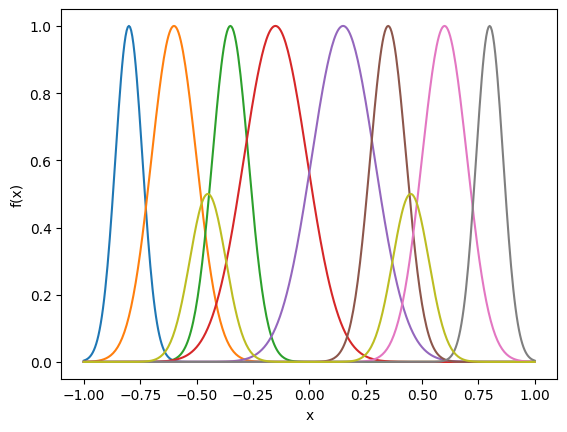

In [8]:
gaussian_params = [
        (-0.80, 0.06),
        (-0.60, 0.10),
        (-0.35, 0.08),
        (-0.15, 0.14),
        ( 0.15, 0.14),
        ( 0.35, 0.08),
        ( 0.60, 0.10),
        ( 0.80, 0.06),
    ]

for k, (mu, sigma) in enumerate(gaussian_params, start=1):
    f = np.exp(-((xgrid - mu) ** 2) / (2.0 * sigma ** 2))
    plt.plot(xgrid, f)
    plt.xlabel("x")
    plt.ylabel("f(x)")
f_bimodal = (
        0.5 * np.exp(-((xgrid + 0.45) ** 2) / (2.0 * 0.08 ** 2)) +
        0.5 * np.exp(-((xgrid - 0.45) ** 2) / (2.0 * 0.08 ** 2))
    )
plt.plot(xgrid, f_bimodal)
plt.xlabel("x")

left_step integral = 1.0 min = 0.1578934177859766
right_step integral = 0.9999999999999999 min = 0.1578934177859766
three_step integral = 1.0 min = 0.09155613656058037
reverse_three_step integral = 1.0 min = 0.09155613656058038
left_edge_layer integral = 1.0 min = 0.15002557434143365
right_edge_layer integral = 0.9999999999999998 min = 0.15002557434143363
soft_ramp_up integral = 1.0 min = 0.042080864336703334
soft_ramp_down integral = 1.0000000000000002 min = 0.04208086433670334
central_peak integral = 1.0 min = 0.06578947382057032
alternating_steps integral = 1.0 min = 0.10339002961315515


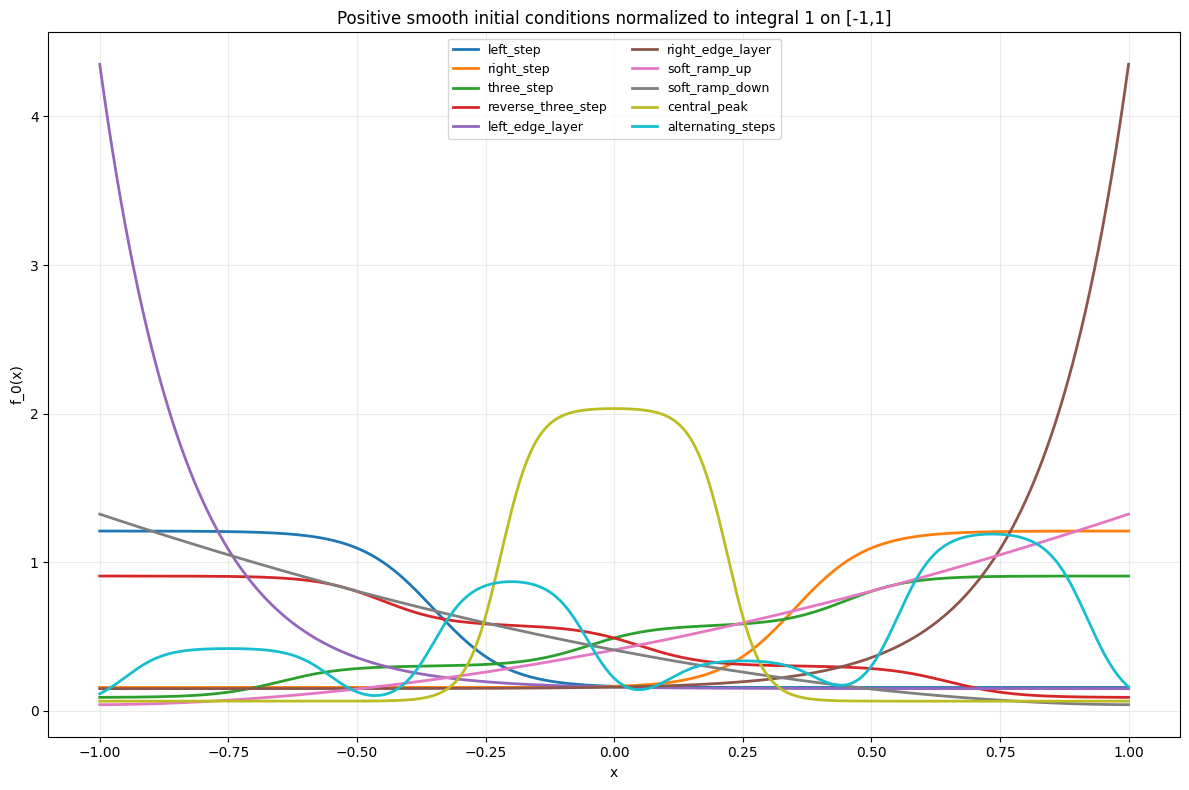

In [32]:
import numpy as np
import matplotlib.pyplot as plt


def normalize_to_unit_integral(f, xgrid):
    mass = np.trapz(f, xgrid)
    if np.isclose(mass, 0.0):
        raise ValueError("Integral is too close to zero to normalize to 1.")
    return f / mass


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def smooth_box(x, left, right, sharpness=25.0):
    return sigmoid(sharpness * (x - left)) - sigmoid(sharpness * (x - right))


def smooth_initial_condition(xgrid, mode="left_step", normalize=True):
    x = np.asarray(xgrid, dtype=float)

    if mode == "left_step":
        # high on left, low on right
        f = 0.15 + 1.0 * sigmoid(-14.0 * (x + 0.35))

    elif mode == "right_step":
        # low on left, high on right
        f = 0.15 + 1.0 * sigmoid(14.0 * (x - 0.35))

    elif mode == "three_step":
        # increasing three-step profile
        f = (
            0.15
            + 0.35 * sigmoid(16.0 * (x + 0.65))
            + 0.45 * sigmoid(16.0 * (x + 0.05))
            + 0.55 * sigmoid(16.0 * (x - 0.45))
        )

    elif mode == "reverse_three_step":
        # decreasing three-step profile
        f = (
            0.15
            + 0.55 * sigmoid(-16.0 * (x + 0.45))
            + 0.45 * sigmoid(-16.0 * (x - 0.05))
            + 0.35 * sigmoid(-16.0 * (x - 0.65))
        )

    elif mode == "left_edge_layer":
        f = 0.05 + 1.4 * np.exp(-6.0 * (x + 1.0))

    elif mode == "right_edge_layer":
        f = 0.05 + 1.4 * np.exp(6.0 * (x - 1.0))

    elif mode == "soft_ramp_up":
        f = 0.12 + 1.05 * (x + 1.0) ** 1.8

    elif mode == "soft_ramp_down":
        f = 0.12 + 1.05 * (1.0 - x) ** 1.8

    elif mode == "central_peak":
        # central plateau / peak, positive everywhere
        f = 0.10 + 3.0 * smooth_box(x, -0.22, 0.22, sharpness=30.0)

    elif mode == "alternating_steps":
        # multi-plateau positive profile, keeping the "alternating structure" feel
        f = (
            0.08
            + 1.0 * smooth_box(x, -0.95, -0.55, sharpness=26.0)
            + 2.2 * smooth_box(x, -0.35, -0.05, sharpness=28.0)
            + 0.8 * smooth_box(x, 0.10, 0.40, sharpness=28.0)
            + 3.0 * smooth_box(x, 0.55, 0.92, sharpness=26.0)
        )

    else:
        raise ValueError(f"Unknown mode: {mode}")

    f = np.maximum(f, 1e-10)

    if normalize:
        f = normalize_to_unit_integral(f, xgrid)

    return f


# Grid on [-1,1]
xgrid = np.linspace(-1.0, 1.0, 1200)

modes = [
    "left_step",
    "right_step",
    "three_step",
    "reverse_three_step",
    "left_edge_layer",
    "right_edge_layer",
    "soft_ramp_up",
    "soft_ramp_down",
    "central_peak",
    "alternating_steps",
]

plt.figure(figsize=(12, 8))
for mode in modes:
    f = smooth_initial_condition(xgrid, mode=mode, normalize=True)
    print(mode, "integral =", np.trapz(f, xgrid), "min =", np.min(f))
    plt.plot(xgrid, f, lw=2, label=mode)

plt.xlabel("x")
plt.ylabel("f_0(x)")
plt.title("Positive smooth initial conditions normalized to integral 1 on [-1,1]")
plt.legend(ncol=2, fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## NN for the invers problem(New Version)

In [ ]:
import numpy as np
import tensorflow as tf

# Assumptions: Run the forward block first
# Generated dataset:
#   X_meas : shape (20, 10, 41) X is basically M(a,f0,t) 
#   F0     : shape (10, 401)
#   times  : shape (41,)
#   thresholds : shape (10,)
#   xgrid  : shape (401,)

def make_distance_grid(xgrid, num_r=100):
    # Kernel is represented as kappa(r) for r in [0, xmax-xmin]
    r_max = float(xgrid[-1] - xgrid[0])
    rgrid = np.linspace(0.0, r_max, num_r, dtype=np.float32)
    return rgrid


def make_theta_from_kappa(rgrid, kappa_values):
    # Build theta(x, y) = kappa(|x-y|) by linear interpolation on rgrid
    rgrid = np.asarray(rgrid, dtype=float)
    kappa_values = np.asarray(kappa_values, dtype=float)

    def theta(x, y):
        x_arr = np.asarray(x, dtype=float)
        y_arr = np.asarray(y, dtype=float)
        d = np.abs(x_arr - y_arr)
        return np.interp(d, rgrid, kappa_values)

    return theta


def measurements_from_snapshots(snapshots, xgrid, thresholds):
    # Making M for different a
    n_times = len(snapshots)
    n_a = len(thresholds)

    M = np.empty((n_a, n_times), dtype=np.float32)

    for j, f in enumerate(snapshots):
        for i, a in enumerate(thresholds):
            M[i, j] = cumulative_data(f, xgrid, a)

    return M


def simulate_measurements_for_all_f0(F0, xgrid, thresholds, dt, steps, gamma, P, dP, Phi, theta, A=None):
    # Making M for all f-0(and calling the other func for all a)
    X_pred = []

    for k in range(F0.shape[0]):
        snapshots = run_forward_problem(
            f_init=F0[k],
            xgrid=xgrid,
            dt=dt,
            steps=steps,
            gamma=gamma,
            P=P,
            dP=dP,
            Phi=Phi,
            theta_used=theta,
            A=A
        )
        M = measurements_from_snapshots(snapshots, xgrid, thresholds)
        X_pred.append(M)

    return np.stack(X_pred, axis=0).astype(np.float32)


# 2. Model
# ============================================================

def build_kernel_model(n_f0, n_a, n_t, n_x, num_r):
    # Inputs:
    #   X_meas: (n_f0, n_a, n_t)
    #   F0    : (n_f0, n_x)
    # Output:
    #   kappa(r) on a fixed r-grid, shape (num_r,)

    meas_input = tf.keras.Input(shape=(n_f0, n_a, n_t), name="X_meas_input")
    f0_input   = tf.keras.Input(shape=(n_f0, n_x), name="F0_input")

    # Flatten both
    x1 = tf.keras.layers.Flatten()(meas_input)
    x2 = tf.keras.layers.Flatten()(f0_input)

    # Combine
    x = tf.keras.layers.Concatenate()([x1, x2])

    # Small network
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)

    # Output kernel
    raw_out = tf.keras.layers.Dense(num_r, activation=None)(x)
    kappa_out = tf.keras.layers.Activation(tf.nn.softplus, name="kappa_output")(raw_out)

    model = tf.keras.Model(inputs=[meas_input, f0_input], outputs=kappa_out)
    return model


# ============================================================
# 3. Training wrapper
# ============================================================

class KernelInverseTrainer:
    # Trains one shared kernel using all experiments together.
    # Since the solver is NumPy-based and not differentiable through TF,
    # we do local search in kernel space and then distill the best candidate.

    def __init__(
        self,
        model,
        xgrid,
        thresholds,
        dt,
        steps,
        gamma,
        P,
        dP,
        Phi,
        num_r=100,
        search_scale=0.02,
        random_seed=0
    ):
        self.model = model
        self.xgrid = np.asarray(xgrid, dtype=np.float32)
        self.thresholds = np.asarray(thresholds, dtype=np.float32)
        self.dt = float(dt)
        self.steps = int(steps)
        self.gamma = gamma
        self.P = P
        self.dP = dP
        self.Phi = Phi
        self.rgrid = make_distance_grid(self.xgrid, num_r=num_r)
        self.search_scale = float(search_scale)
        self.rng = np.random.default_rng(random_seed)

        # precompute once
        self.A = prime_x(self.xgrid, self.gamma, self.P, self.dP, self.Phi)

    def predict_kappa(self, X_meas, F0):
        X_in = X_meas[np.newaxis, ...].astype(np.float32)
        F0_in = F0[np.newaxis, ...].astype(np.float32)
        kappa = self.model.predict([X_in, F0_in], verbose=0)[0]
        return kappa.astype(np.float32)

    def evaluate_loss(self, kappa, X_target, F0):
        theta = make_theta_from_kappa(self.rgrid, kappa)

        X_pred = simulate_measurements_for_all_f0(
            F0=F0,
            xgrid=self.xgrid,
            thresholds=self.thresholds,
            dt=self.dt,
            steps=self.steps,
            gamma=self.gamma,
            P=self.P,
            dP=self.dP,
            Phi=self.Phi,
            theta=theta,
            A=self.A
        )

        loss = np.mean((X_pred - X_target) ** 2, dtype=np.float64)
        return float(loss), X_pred

    def local_random_search(self, base_kappa, X_target, F0, n_candidates=3):
        best_kappa = np.maximum(base_kappa, 1e-8)
        best_loss, best_pred = self.evaluate_loss(best_kappa, X_target, F0)

        for _ in range(n_candidates):
            noise = self.rng.normal(loc=0.0, scale=self.search_scale, size=base_kappa.shape)
            candidate = np.maximum(base_kappa + noise.astype(np.float32), 1e-8)
            candidate = np.minimum(candidate, 5.0)

            loss, X_pred = self.evaluate_loss(candidate, X_target, F0)
            if loss < best_loss:
                best_loss = loss
                best_kappa = candidate
                best_pred = X_pred

        return best_kappa, best_loss, best_pred

    def fit(self, X_meas, F0, epochs=20, lr=5e-5, n_search=3, verbose_every=1):
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=lr,
            weight_decay=1e-5,
            clipnorm=1.0
        )
        mse = tf.keras.losses.MeanSquaredError()

        history = {
            "physics_loss": [],
            "distill_loss": []
        }

        X_in = X_meas[np.newaxis, ...].astype(np.float32)
        F0_in = F0[np.newaxis, ...].astype(np.float32)

        best_global_kappa = None
        best_global_loss = np.inf
        best_global_pred = None

        for epoch in range(1, epochs + 1):
            # current NN prediction
            kappa_pred = self.model.predict([X_in, F0_in], verbose=0)[0].astype(np.float32)

            # search nearby kernels using true physics loss
            kappa_target, physics_loss, X_pred = self.local_random_search(
                base_kappa=kappa_pred,
                X_target=X_meas,
                F0=F0,
                n_candidates=n_search
            )

            if physics_loss < best_global_loss:
                best_global_loss = physics_loss
                best_global_kappa = kappa_target.copy()
                best_global_pred = X_pred.copy()

            # checkpoint
            np.savez(
                "checkpoint_kernel.npz",
                kappa=best_global_kappa,
                loss=best_global_loss,
                X_pred=best_global_pred
            )

            # supervised fit toward best local candidate
            with tf.GradientTape() as tape:
                kappa_out = self.model([X_in, F0_in], training=True)
                distill_loss = mse(kappa_target[np.newaxis, :], kappa_out)

            grads = tape.gradient(distill_loss, self.model.trainable_variables)

            # optional safety: replace None gradients
            grads_vars = [
                (g, v) for g, v in zip(grads, self.model.trainable_variables) if g is not None
            ]
            optimizer.apply_gradients(grads_vars)

            history["physics_loss"].append(physics_loss)
            history["distill_loss"].append(float(distill_loss.numpy()))

            if epoch % verbose_every == 0 or epoch == 1:
                print(
                    f"Epoch {epoch:4d} | "
                    f"physics_loss = {physics_loss:.6e} | "
                    f"distill_loss = {float(distill_loss.numpy()):.6e}"
                )

        return {
            "history": history,
            "best_kappa": best_global_kappa,
            "best_physics_loss": best_global_loss,
            "best_X_pred": best_global_pred,
            "rgrid": self.rgrid
        }

# 4. Example
# ============================================================
# Generate X_meas, F0, times, thresholds, xgrid first
# and define: gamma, P, dP, Phi, dt, steps

# Normalize measurements before training
X_scale = np.maximum(np.max(np.abs(X_meas)), 1e-8)
X_meas = X_meas / X_scale

n_f0, n_a, n_t = X_meas.shape
n_x = F0.shape[1]
num_r = 50

model = build_kernel_model(
    n_f0=n_f0,
    n_a=n_a,
    n_t=n_t,
    n_x=n_x,
    num_r=num_r
)

trainer = KernelInverseTrainer(
    model=model,
    xgrid=xgrid,
    thresholds=thresholds,
    dt=dt,
    steps=steps,
    gamma=gamma,
    P=P,
    dP=dP,
    Phi=Phi,
    num_r=num_r,
    search_scale=0.005,
    random_seed=0
)

results = trainer.fit(
    X_meas=X_meas,
    F0=F0,
    epochs=10,
    lr=5e-5,
    n_search=3,
    verbose_every=1
)

kappa_learned = results["best_kappa"]
rgrid = results["rgrid"]

print("\nBest physics loss:", results["best_physics_loss"])
print("Learned kernel shape:", kappa_learned.shape)

Epoch    1 | physics_loss = 3.118925e-02 | distill_loss = 3.940672e-01
Epoch    2 | physics_loss = 3.295513e-02 | distill_loss = 6.395001e-01
Epoch    3 | physics_loss = 3.431404e-02 | distill_loss = 7.226117e-01
Epoch    4 | physics_loss = 3.513577e-02 | distill_loss = 7.409132e-01
Epoch    5 | physics_loss = 3.597151e-02 | distill_loss = 8.155308e-01
Epoch    6 | physics_loss = 3.671714e-02 | distill_loss = 8.898979e-01
Epoch    7 | physics_loss = 3.731957e-02 | distill_loss = 9.507321e-01
Epoch    8 | physics_loss = 3.790338e-02 | distill_loss = 1.073411e+00
Epoch    9 | physics_loss = 3.849001e-02 | distill_loss = 1.230953e+00
Epoch   10 | physics_loss = 3.909796e-02 | distill_loss = 1.441579e+00

Best physics loss: 0.031189246204593565
Learned kernel shape: (50,)


In [29]:
np.savez(
    "nn_run_results.npz",
    rgrid=results["rgrid"],
    kappa_learned=results["best_kappa"],
    best_physics_loss=results["best_physics_loss"],
    X_pred=results["best_X_pred"],
    X_meas=X_meas,
    F0=F0,
    times=times,
    thresholds=thresholds,
    meta_names=meta_names,
)

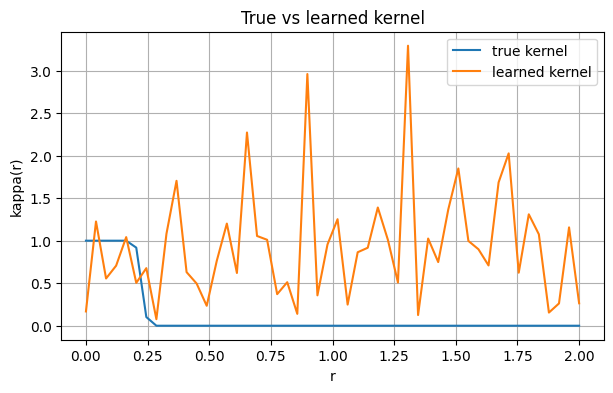

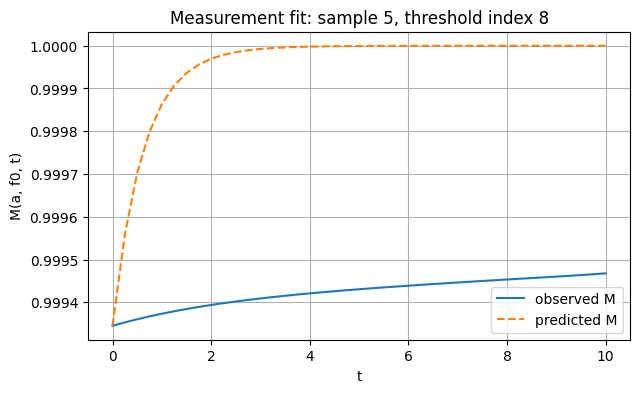

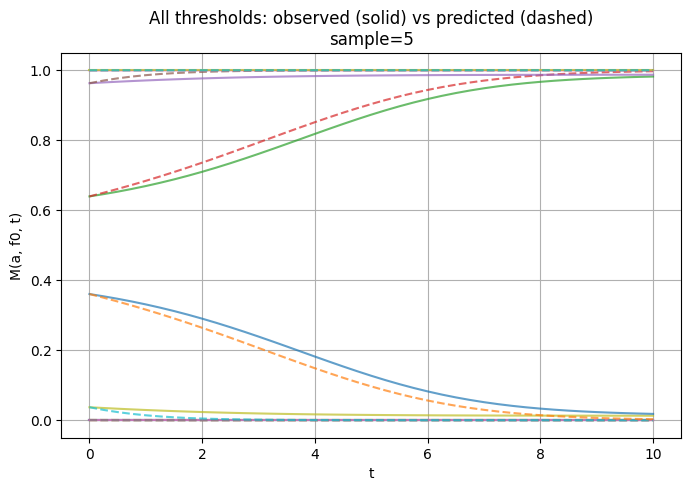

In [42]:
import matplotlib.pyplot as plt
import numpy as np
data=np.load("nn_run_results.npz")
rgrid = data["rgrid"]
kappa_learned = data["kappa_learned"]

def true_kappa(r):
    r0 = 0.2
    s = 0.05
    r = np.asarray(r)
    center = (r <= r0).astype(float)
    slope = ((r > r0) & (r < r0 + s)).astype(float) * (-r / s + (r0 + s) / s)
    return center + slope

kappa_true = true_kappa(rgrid)

plt.figure(figsize=(7, 4))
plt.plot(rgrid, kappa_true, label="true kernel")
plt.plot(rgrid, kappa_learned, label="learned kernel")
plt.xlabel("r")
plt.ylabel("kappa(r)")
plt.title("True vs learned kernel")
plt.legend()
plt.grid(True)
plt.show()

X_pred = results["best_X_pred"]

sample_id = 5 #between 0 and 19
a_id = 8 #between 0 and 9

plt.figure(figsize=(7, 4))
plt.plot(times, X_meas[sample_id, a_id, :], label="observed M")
plt.plot(times, X_pred[sample_id, a_id, :], "--", label="predicted M")
plt.xlabel("t")
plt.ylabel("M(a, f0, t)")
plt.title(f"Measurement fit: sample {sample_id}, threshold index {a_id}")
plt.legend()
plt.grid(True)
plt.show()

sample_id = 5

plt.figure(figsize=(8, 5))
for a_id in range(len(thresholds)):
    plt.plot(times, X_meas[sample_id, a_id, :], alpha=0.7)
    plt.plot(times, X_pred[sample_id, a_id, :], "--", alpha=0.7)

plt.xlabel("t")
plt.ylabel("M(a, f0, t)")
plt.title(f"All thresholds: observed (solid) vs predicted (dashed)\nsample={sample_id}")
plt.grid(True)
plt.show()

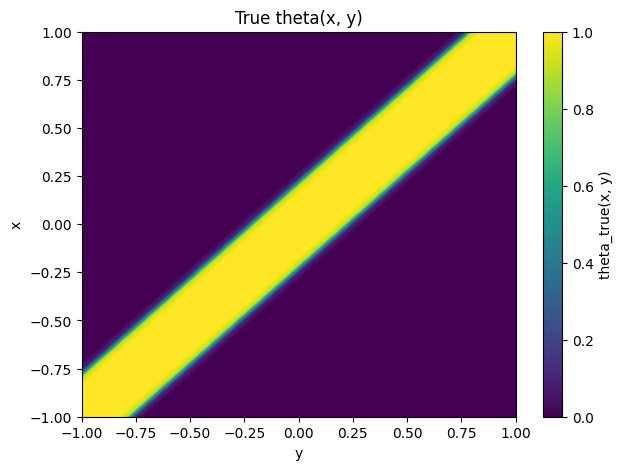

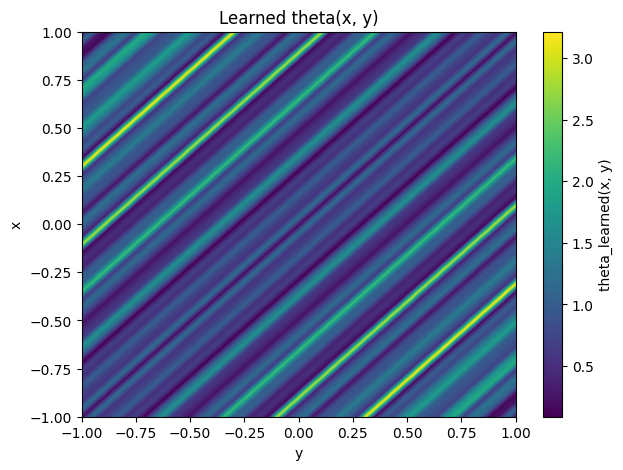

In [39]:
import numpy as np
import matplotlib.pyplot as plt

rgrid = results["rgrid"]
kappa_learned = results["best_kappa"]

def true_kappa(r):
    r0 = 0.2
    s = 0.05
    r = np.asarray(r)
    center = (r <= r0).astype(float)
    slope = ((r > r0) & (r < r0 + s)).astype(float) * (-r / s + (r0 + s) / s)
    return center + slope

kappa_true = true_kappa(rgrid)

def make_theta_matrix_from_kappa(xgrid, rgrid, kappa_values):
    X, Y = np.meshgrid(xgrid, xgrid, indexing="ij")
    D = np.abs(X - Y)
    theta_mat = np.interp(D, rgrid, kappa_values)
    return theta_mat

theta_true_mat = make_theta_matrix_from_kappa(xgrid, rgrid, kappa_true)
theta_learned_mat = make_theta_matrix_from_kappa(xgrid, rgrid, kappa_learned)

plt.figure(figsize=(7, 5))
plt.imshow(
    theta_true_mat,
    extent=[xgrid[0], xgrid[-1], xgrid[0], xgrid[-1]],
    origin="lower",
    aspect="auto"
)
plt.colorbar(label="theta_true(x, y)")
plt.xlabel("y")
plt.ylabel("x")
plt.title("True theta(x, y)")
plt.show()

plt.figure(figsize=(7, 5))
plt.imshow(
    theta_learned_mat,
    extent=[xgrid[0], xgrid[-1], xgrid[0], xgrid[-1]],
    origin="lower",
    aspect="auto"
)
plt.colorbar(label="theta_learned(x, y)")
plt.xlabel("y")
plt.ylabel("x")
plt.title("Learned theta(x, y)")
plt.show()

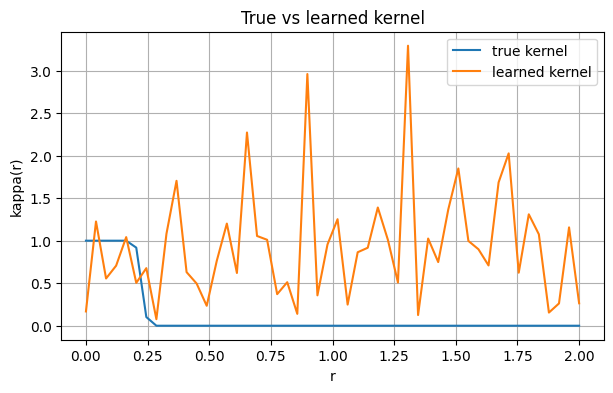

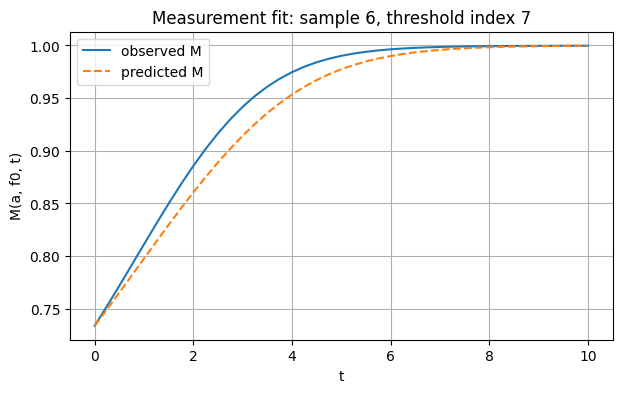

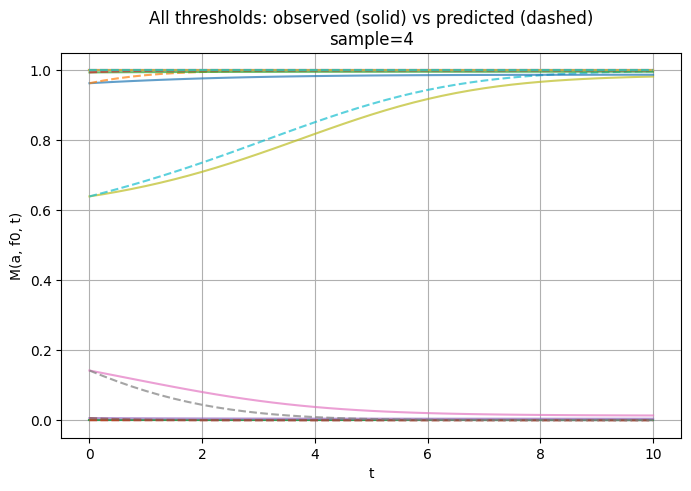

In [38]:
import matplotlib.pyplot as plt
import numpy as np

rgrid = results["rgrid"]
kappa_learned = results["best_kappa"]

def true_kappa(r):
    r0 = 0.2
    s = 0.05
    r = np.asarray(r)
    center = (r <= r0).astype(float)
    slope = ((r > r0) & (r < r0 + s)).astype(float) * (-r / s + (r0 + s) / s)
    return center + slope

kappa_true = true_kappa(rgrid)

plt.figure(figsize=(7, 4))
plt.plot(rgrid, kappa_true, label="true kernel")
plt.plot(rgrid, kappa_learned, label="learned kernel")
plt.xlabel("r")
plt.ylabel("kappa(r)")
plt.title("True vs learned kernel")
plt.legend()
plt.grid(True)
plt.show()

X_pred = results["best_X_pred"]

sample_id = 6
a_id = 7

plt.figure(figsize=(7, 4))
plt.plot(times, X_meas[sample_id, a_id, :], label="observed M")
plt.plot(times, X_pred[sample_id, a_id, :], "--", label="predicted M")
plt.xlabel("t")
plt.ylabel("M(a, f0, t)")
plt.title(f"Measurement fit: sample {sample_id}, threshold index {a_id}")
plt.legend()
plt.grid(True)
plt.show()

sample_id = 4

plt.figure(figsize=(8, 5))
for a_id in range(len(thresholds)):
    plt.plot(times, X_meas[sample_id, a_id, :], alpha=0.7)
    plt.plot(times, X_pred[sample_id, a_id, :], "--", alpha=0.7)

plt.xlabel("t")
plt.ylabel("M(a, f0, t)")
plt.title(f"All thresholds: observed (solid) vs predicted (dashed)\nsample={sample_id}")
plt.grid(True)
plt.show()

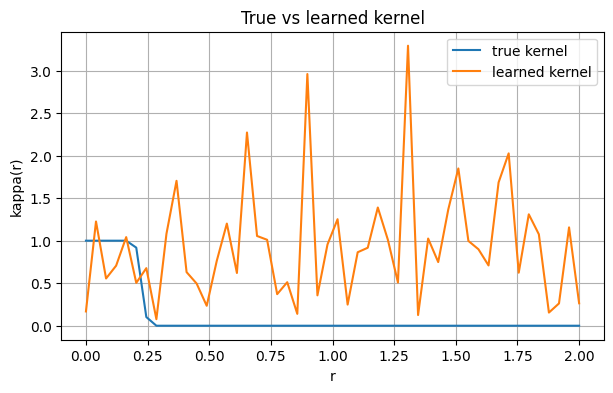

NameError: name 'times' is not defined

<Figure size 700x400 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt
import numpy as np
data=np.load("nn_run_results.npz")
rgrid = data["rgrid"]
kappa_learned = data["kappa_learned"]

def true_kappa(r):
    r0 = 0.2
    s = 0.05
    r = np.asarray(r)
    center = (r <= r0).astype(float)
    slope = ((r > r0) & (r < r0 + s)).astype(float) * (-r / s + (r0 + s) / s)
    return center + slope

kappa_true = true_kappa(rgrid)

plt.figure(figsize=(7, 4))
plt.plot(rgrid, kappa_true, label="true kernel")
plt.plot(rgrid, kappa_learned, label="learned kernel")
plt.xlabel("r")
plt.ylabel("kappa(r)")
plt.title("True vs learned kernel")
plt.legend()
plt.grid(True)
plt.show()

X_pred = data["X_pred"]

sample_id = 5 #between 0 and 19
a_id = 8 #between 0 and 9

plt.figure(figsize=(7, 4))
plt.plot(times, X_meas[sample_id, a_id, :], label="observed M")
plt.plot(times, X_pred[sample_id, a_id, :], "--", label="predicted M")
plt.xlabel("t")
plt.ylabel("M(a, f0, t)")
plt.title(f"Measurement fit: sample {sample_id}, threshold index {a_id}")
plt.legend()
plt.grid(True)
plt.show()

sample_id = 5

plt.figure(figsize=(8, 5))
for a_id in range(len(thresholds)):
    plt.plot(times, X_meas[sample_id, a_id, :], alpha=0.7)
    plt.plot(times, X_pred[sample_id, a_id, :], "--", alpha=0.7)

plt.xlabel("t")
plt.ylabel("M(a, f0, t)")
plt.title(f"All thresholds: observed (solid) vs predicted (dashed)\nsample={sample_id}")
plt.grid(True)
plt.show()

In [7]:
import numpy as np
data = np.load("nn_run_results.npz")
print(data.files)        # shows available keys
X_pred = data["X_pred"]  # load the saved predictions

['rgrid', 'kappa_learned', 'best_physics_loss', 'X_pred', 'X_meas', 'F0', 'times', 'thresholds', 'meta_names']


## NN for a fixed radius

Loaded observed data:
X_obs shape = (5, 5, 201)
times shape = (201,)
a_values = [-0.8 -0.6 -0.3  0.2  0.5]
xgrid shape = (401,)
Using device: cpu
obs_time_idx = [ 0  2  4  6  8 10]
Epoch    1 | total=7.495633e-06 | data=1.336472e-06 | smooth=4.655566e-09 | sym=0.000000e+00
Epoch   10 | total=6.462406e-06 | data=1.358706e-06 | smooth=6.213857e-08 | sym=0.000000e+00
Saved learned result to learned_kernel_from_measurements.npz


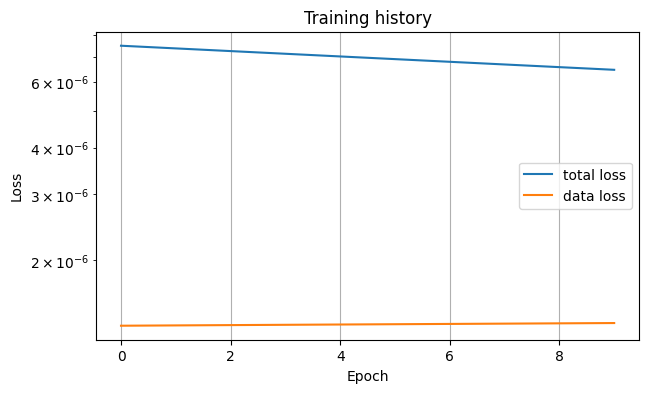

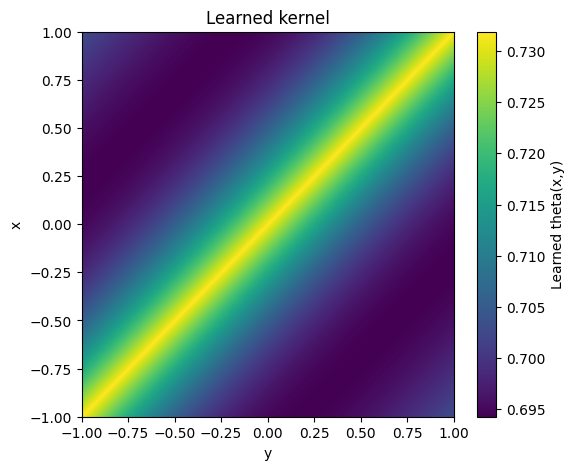

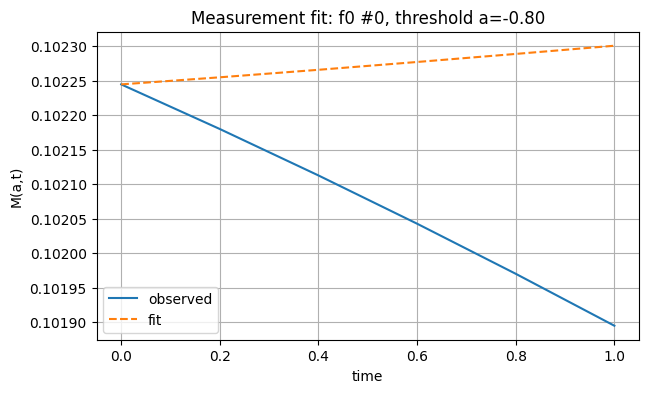

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# 0. Load observed dataset
# ============================================================

data = np.load("dataset_theta1_fixed_r02.npz")
X_obs = data["X"]              # shape (5, 5, 201)
times = data["times"]          # shape (201,)
a_values = data["a_values"]    # shape (5,)
xgrid = data["xgrid"]          # shape (401,)

print("Loaded observed data:")
print("X_obs shape =", X_obs.shape)
print("times shape =", times.shape)
print("a_values =", a_values)
print("xgrid shape =", xgrid.shape)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# convert observations to torch
X_obs_torch = torch.tensor(X_obs, dtype=torch.float32, device=device)
xgrid_torch = torch.tensor(xgrid, dtype=torch.float32, device=device)
a_values_torch = torch.tensor(a_values, dtype=torch.float32, device=device)

xmin = float(xgrid[0])
xmax = float(xgrid[-1])
dx = float(xgrid[1] - xgrid[0])

# ============================================================
# 1. Fixed model ingredients (same as your generator)
# ============================================================

gamma = 0.2
T = 1.0
dt = 0.02
dt_save = 0.2

def P_torch(x):
    return torch.ones_like(x)

def dP_torch(x):
    return torch.zeros_like(x)

def Phi_torch(x):
    return x

# ============================================================
# 2. Initial conditions (must match dataset generator)
# ============================================================

def normalize_density_torch(f, dx):
    mass = torch.sum(f) * dx
    return f / (mass + 1e-14)

def gaussian_density_torch(xgrid, mu, sigma):
    f = torch.exp(-((xgrid - mu) ** 2) / (2.0 * sigma ** 2))
    return normalize_density_torch(f, dx)

def constant_density_torch(xgrid):
    f = torch.ones_like(xgrid)
    return normalize_density_torch(f, dx)

def make_initial_conditions_torch(xgrid):
    f0_list = [
        ("constant", constant_density_torch(xgrid)),
        ("gaussian_left_narrow",  gaussian_density_torch(xgrid, mu=-0.70, sigma=0.08)),
        ("gaussian_left_mid",     gaussian_density_torch(xgrid, mu=-0.25, sigma=0.12)),
        ("gaussian_right_mid",    gaussian_density_torch(xgrid, mu= 0.25, sigma=0.10)),
        ("gaussian_right_broad",  gaussian_density_torch(xgrid, mu= 0.70, sigma=0.16)),
    ]
    return f0_list

f0_list = make_initial_conditions_torch(xgrid_torch)

# ============================================================
# 3. Precompute preimages A[i,j]
#    Here P=1 and Phi=id, so explicit formula exists:
#       xp = x - gamma (x - y) = (1-gamma)x + gamma y
#       => x = (xp - gamma y)/(1-gamma)
# ============================================================

def prime_x_explicit_torch(xgrid, gamma):
    xp = xgrid[:, None]     # shape (N,1)
    y = xgrid[None, :]      # shape (1,N)
    A = (xp - gamma * y) / (1.0 - gamma)
    return A

A_torch = prime_x_explicit_torch(xgrid_torch, gamma=gamma)   # shape (N,N)

# ============================================================
# 4. Differentiable 1D interpolation
# ============================================================

def interp1d_toArch(x_query, xgrid, fvals):
    """
    Piecewise-linear interpolation of fvals defined on xgrid.
    x_query: any shape
    xgrid: (N,)
    fvals: (N,)
    returns same shape as x_query
    """
    N = xgrid.numel()

    xq = torch.clamp(x_query, xgrid[0], xgrid[-1])

    idx_right = torch.searchsorted(xgrid, xq.reshape(-1), right=False)
    idx_right = torch.clamp(idx_right, 1, N - 1)
    idx_left = idx_right - 1

    xL = xgrid[idx_left]
    xR = xgrid[idx_right]
    fL = fvals[idx_left]
    fR = fvals[idx_right]

    w = (xq.reshape(-1) - xL) / (xR - xL + 1e-14)
    out = (1.0 - w) * fL + w * fR
    return out.reshape(x_query.shape)

# ============================================================
# 5. Measurement operator M(a)
#    M(a) = integral_{x <= a} f(x) dx
# ============================================================

def compute_measurements_torch(f, xgrid, a_values):
    vals = []
    for a in a_values:
        mask = (xgrid <= a).float()
        vals.append(torch.sum(f * mask) * dx)
    return torch.stack(vals, dim=0)   # shape (n_a,)

# ============================================================
# 6. Generic neural kernel theta(x,y)
#    No bounded-confidence assumption
# ============================================================

class RadialKernelNet(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x, y):
        d = torch.abs(x - y)[..., None]   # shape (..., 1)
        z = self.net(d).squeeze(-1)
        return F.softplus(z)


kernel_model = RadialKernelNet().to(device)

# ============================================================
# 7. Regularization helpers
# ============================================================

def kernel_matrix(model, xgrid):
    X = xgrid[:, None].repeat(1, xgrid.numel())
    Y = xgrid[None, :].repeat(xgrid.numel(), 1)
    return model(X, Y)

def smoothness_penalty(K):
    px = ((K[1:, :] - K[:-1, :]) ** 2).mean()
    py = ((K[:, 1:] - K[:, :-1]) ** 2).mean()
    return px + py

def symmetry_penalty(K):
    return ((K - K.T) ** 2).mean()

# ============================================================
# 8. PDE RHS in torch
# ============================================================

def rhs_torch(f, xgrid, gamma, theta_model, A):
    """
    f: (N,)
    xgrid: (N,)
    A: preimage matrix (N,N)
    """
    N = xgrid.numel()
    y = xgrid

    xi = xgrid[:, None]                  # (N,1)
    yj = y[None, :]                      # (1,N)

    # loss term
    theta_loss = theta_model(xi.expand(N, N), yj.expand(N, N))
    loss = torch.sum(theta_loss * f[:, None] * f[None, :], dim=1) * dx

    # gain term
    A_clamped = torch.clamp(A, xgrid[0], xgrid[-1])
    f_at_A = interp1d_torch(A_clamped, xgrid, f)    # (N,N)

    theta_gain = theta_model(A_clamped, yj.expand(N, N))

    # for P=1, dP=0 => J = |1 - gamma|
    J = abs(1.0 - gamma)

    gain = torch.sum(theta_gain * f_at_A * f[None, :], dim=1) * dx / J

    return gain - loss

# ============================================================
# 9. Simulate and output measurement tensor
# ============================================================

def simulate_measurements_from_kernel(
    theta_model,
    xgrid,
    a_values,
    f0_list,
    T=20.0,
    dt=0.01,
    dt_save=0.1
):
    n_steps = int(round(T / dt))
    save_every = int(round(dt_save / dt))
    n_f0 = len(f0_list)
    n_a = len(a_values)
    n_saved = int(round(T / dt_save)) + 1

    pred = torch.zeros((n_f0, n_a, n_saved), dtype=torch.float32, device=xgrid.device)

    for k, (_, f0) in enumerate(f0_list):
        f = f0.clone()
        f = normalize_density_torch(f, dx)

        save_id = 0
        pred[k, :, save_id] = compute_measurements_torch(f, xgrid, a_values)
        save_id += 1

        for n in range(1, n_steps + 1):
            df = rhs_torch(f, xgrid, gamma, theta_model, A_torch)
            f = f + dt * df
            f = torch.clamp(f, min=0.0)
            f = normalize_density_torch(f, dx)

            if n % save_every == 0:
                pred[k, :, save_id] = compute_measurements_torch(f, xgrid, a_values)
                save_id += 1

    return pred

# ============================================================
# 10. Train kernel by matching observed measurements
# ============================================================

optimizer = torch.optim.Adam(kernel_model.parameters(), lr=1e-3)

n_epochs = 10
lambda_smooth = 1e-3
lambda_sym = 1e-3
lambda_size = 1e-5

history = []
obs_time_idx = np.arange(0, int(round(T / 0.1)) + 1, int(round(dt_save / 0.1)))
print("obs_time_idx =", obs_time_idx)

for epoch in range(n_epochs):
    optimizer.zero_grad()

    X_pred = simulate_measurements_from_kernel(
    theta_model=kernel_model,
    xgrid=xgrid_torch,
    a_values=a_values_torch,
    f0_list=f0_list[:1],
    T=T,
    dt=dt,
    dt_save=dt_save
)

    X_obs_small = X_obs_torch[:1, :, ::2][:, :, :X_pred.shape[2]]
    data_loss = ((X_pred - X_obs_small) ** 2).mean()
    
    K = kernel_matrix(kernel_model, xgrid_torch)
    reg_smooth = smoothness_penalty(K)
    reg_sym = symmetry_penalty(K)
    reg_size = (K ** 2).mean()

    loss = data_loss + lambda_smooth * reg_smooth + lambda_sym * reg_sym + lambda_size * reg_size
    loss.backward()
    optimizer.step()

    history.append([
        loss.item(),
        data_loss.item(),
        reg_smooth.item(),
        reg_sym.item(),
        reg_size.item()
    ])

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:4d} | "
            f"total={loss.item():.6e} | "
            f"data={data_loss.item():.6e} | "
            f"smooth={reg_smooth.item():.6e} | "
            f"sym={reg_sym.item():.6e}"
        )

history = np.array(history)

# ============================================================
# 11. Extract learned kernel on the grid
# ============================================================

kernel_model.eval()
with torch.no_grad():
    K_learned = kernel_matrix(kernel_model, xgrid_torch).cpu().numpy()
    X_fit = simulate_measurements_from_kernel(
        theta_model=kernel_model,
        xgrid=xgrid_torch,
        a_values=a_values_torch,
        f0_list=f0_list,
        T=T,
        dt=dt,
        dt_save=dt_save
    ).cpu().numpy()

np.savez(
    "learned_kernel_from_measurements.npz",
    K_learned=K_learned,
    X_fit=X_fit,
    X_obs=X_obs,
    xgrid=xgrid,
    a_values=a_values,
    times=times
)

print("Saved learned result to learned_kernel_from_measurements.npz")

# ============================================================
# 12. Plots
# ============================================================

plt.figure(figsize=(7, 4))
plt.plot(history[:, 0], label="total loss")
plt.plot(history[:, 1], label="data loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(
    K_learned,
    extent=[xgrid[0], xgrid[-1], xgrid[0], xgrid[-1]],
    origin="lower",
    aspect="auto"
)
plt.colorbar(label="Learned theta(x,y)")
plt.xlabel("y")
plt.ylabel("x")
plt.title("Learned kernel")
plt.show()

# compare one measurement trace
sample_id = 0
a_id = 0

# observed times are on a finer grid; the fitted curve was saved at intervals dt_save.
# use obs_time_idx to select the observation times corresponding to the saved fit times
times_plot = times[obs_time_idx][: X_fit.shape[2]]
obs_plot = X_obs[sample_id, a_id, obs_time_idx][: X_fit.shape[2]]
fit_plot = X_fit[sample_id, a_id, : X_fit.shape[2]]

plt.figure(figsize=(7, 4))
plt.plot(times_plot, obs_plot, label="observed")
plt.plot(times_plot, fit_plot, "--", label="fit")
plt.xlabel("time")
plt.ylabel("M(a,t)")
plt.title(f"Measurement fit: f0 #{sample_id}, threshold a={a_values[a_id]:.2f}")
plt.legend()
plt.grid(True)
plt.show()

## NN PART for BC with DIFFERENT r

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class OpinionMDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class RadiusNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        # softplus keeps the predicted radius positive
        return torch.nn.functional.softplus(self.net(x)) + 1e-6
    
    def train_radius_net(model, train_loader, val_loader=None, epochs=100, lr=1e-3, device="cpu"):
        model = model.to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.MSELoss()

        history = {"train_loss": [], "val_loss": []}

        for epoch in range(epochs):
            model.train()
            train_loss = 0.0

            for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                optimizer.zero_grad()
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                loss.backward()
                optimizer.step()

                train_loss += loss.item() * X_batch.size(0)

            train_loss /= len(train_loader.dataset)
            history["train_loss"].append(train_loss)

            if val_loader is not None:
                model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for X_batch, y_batch in val_loader:
                        X_batch = X_batch.to(device)
                        y_batch = y_batch.to(device)
                        y_pred = model(X_batch)
                        loss = criterion(y_pred, y_batch)
                        val_loss += loss.item() * X_batch.size(0)

                val_loss /= len(val_loader.dataset)
                history["val_loss"].append(val_loss)
                print(f"Epoch {epoch+1:3d} | train loss = {train_loss:.6e} | val loss = {val_loss:.6e}")
            else:
                print(f"Epoch {epoch+1:3d} | train loss = {train_loss:.6e}")

        return history

In [10]:
#Full example for bounded confidence
import matplotlib.pyplot as plt

# ---------------- Numerical parameters ----------------
N = 400
xgrid = np.linspace(-1.0, 1.0, N)

dt = 0.5
T = 20
steps = int(T / dt)

# Example choices already in code:
# Phi = Phi_0
# theta will be replaced sample-by-sample in dataset generation
# P(x) = 1, dP(x) = 0
# gamma = 0.5

thresholds = [-0.8, -0.6, -0.3, 0.2, 0.5]

# ---------------- Generate synthetic dataset ----------------
X, y = generate_bc_dataset(
    num_samples=300,
    xgrid=xgrid,
    dt=dt,
    steps=steps,
    gamma=gamma,
    P=P,
    dP=dP,
    Phi=Phi,
    thresholds=thresholds,
    radius_range=(0.05, 0.5),
    use_two_initial_conditions=True,
    time_stride=2,
    seed=1
)



In [12]:
# All the BC data easy to load in Python using data = np.load("bc_dataset.npz")
#X = data["X"]
#y = data["y"]
np.savez("bc_dataset.npz", X=X, y=y)
print("saved dataset with shapes:", X.shape, y.shape)
#saving as csv just in case
np.savetxt("X.csv", X, delimiter=",")
np.savetxt("y.csv", y, delimiter=",")

saved dataset with shapes: (300, 110) (300, 1)


Loaded dataset:
X shape = (300, 110)
y shape = (300, 1)
Using device: cpu
Epoch   1 | train loss = 9.695958e-02 | val loss = 2.164219e-02
Epoch   2 | train loss = 2.082920e-02 | val loss = 2.610228e-02
Epoch   3 | train loss = 2.677378e-02 | val loss = 2.201497e-02
Epoch   4 | train loss = 2.015215e-02 | val loss = 1.634036e-02
Epoch   5 | train loss = 1.920149e-02 | val loss = 1.642763e-02
Epoch   6 | train loss = 1.806559e-02 | val loss = 1.628426e-02
Epoch   7 | train loss = 1.768302e-02 | val loss = 1.592277e-02
Epoch   8 | train loss = 1.729873e-02 | val loss = 1.543510e-02
Epoch   9 | train loss = 1.716944e-02 | val loss = 1.518166e-02
Epoch  10 | train loss = 1.692152e-02 | val loss = 1.509735e-02
Epoch  11 | train loss = 1.661304e-02 | val loss = 1.469856e-02
Epoch  12 | train loss = 1.625686e-02 | val loss = 1.463277e-02
Epoch  13 | train loss = 1.601099e-02 | val loss = 1.413852e-02
Epoch  14 | train loss = 1.562154e-02 | val loss = 1.389272e-02
Epoch  15 | train loss = 1.520

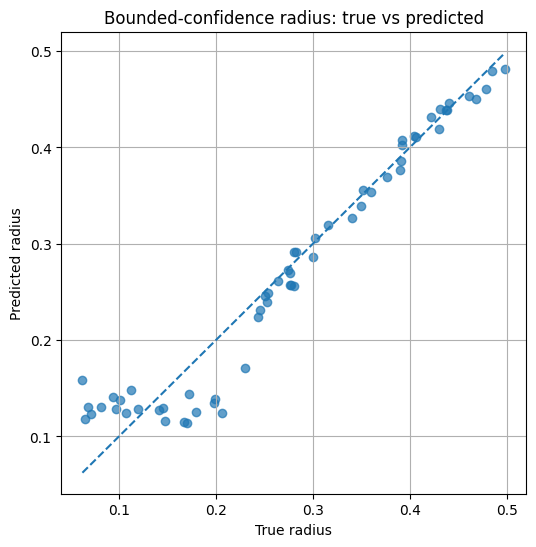

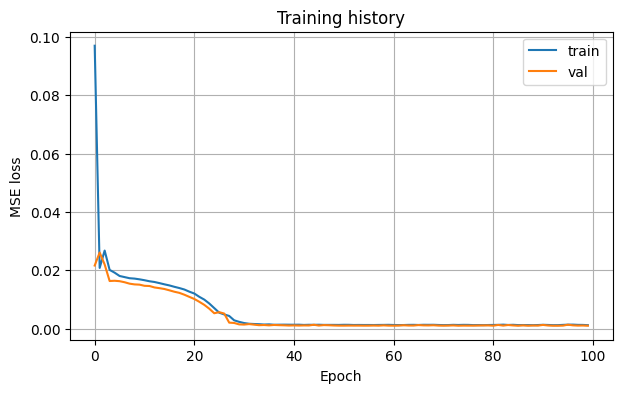

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ---------------- Load dataset ----------------
dataset_path = "bc_dataset.npz"

if not os.path.exists(dataset_path):
    raise FileNotFoundError(
        f"Could not find {dataset_path}. Make sure you saved the dataset first."
    )

data = np.load(dataset_path)
X = data["X"]
y = data["y"]

print("Loaded dataset:")
print("X shape =", X.shape)
print("y shape =", y.shape)


# ---------------- Dataset wrapper ----------------
class OpinionMDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ---------------- Model ----------------
class RadiusNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return torch.nn.functional.softplus(self.net(x)) + 1e-6


# ---------------- Missing training function ----------------
def train_radius_net(model, train_loader, val_loader=None, epochs=100, lr=1e-3, device="cpu"):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)
        history["train_loss"].append(train_loss)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0

            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.to(device)
                    y_batch = y_batch.to(device)

                    y_pred = model(X_batch)
                    loss = criterion(y_pred, y_batch)
                    val_loss += loss.item() * X_batch.size(0)

            val_loss /= len(val_loader.dataset)
            history["val_loss"].append(val_loss)

            print(
                f"Epoch {epoch+1:3d} | "
                f"train loss = {train_loss:.6e} | "
                f"val loss = {val_loss:.6e}"
            )
        else:
            print(f"Epoch {epoch+1:3d} | train loss = {train_loss:.6e}")

    return history

import numpy as np
from torch.utils.data import DataLoader

# ---------------- Random train/validation split ----------------
n = len(X)
n_train = int(0.8 * n)

perm = np.random.permutation(n)

train_idx = perm[:n_train]
val_idx = perm[n_train:]

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

train_ds = OpinionMDataset(X_train, y_train)
val_ds = OpinionMDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)


# ---------------- Build and train model ----------------
input_dim = X.shape[1]
model = RadiusNet(input_dim=input_dim, hidden_dim=128)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

history = train_radius_net(
    model,
    train_loader,
    val_loader=val_loader,
    epochs=100,
    lr=1e-3,
    device=device
)


# ---------------- Helper for single prediction ----------------
def predict_radius_from_measurements(model, feature_vector, device="cpu"):
    model.eval()
    x = torch.tensor(feature_vector[None, :], dtype=torch.float32).to(device)
    with torch.no_grad():
        pred = model(x).cpu().numpy()[0, 0]
    return pred


# ---------------- Quick test on one validation sample ----------------
idx = 0
pred_radius = predict_radius_from_measurements(model, X_val[idx], device=device)
true_radius = y_val[idx, 0]

print("Example validation sample:")
print("true radius      =", true_radius)
print("predicted radius =", pred_radius)


# ---------------- Plot predicted vs true radius on validation set ----------------
model.eval()
preds = []

with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch).cpu().numpy()
        preds.append(y_pred)

preds = np.vstack(preds).flatten()
truth = y_val.flatten()

plt.figure(figsize=(6, 6))
plt.scatter(truth, preds, alpha=0.7)
plt.plot([truth.min(), truth.max()], [truth.min(), truth.max()], "--")
plt.xlabel("True radius")
plt.ylabel("Predicted radius")
plt.title("Bounded-confidence radius: true vs predicted")
plt.grid(True)
plt.show()


# ---------------- Optional: plot training history ----------------
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="train")
if len(history["val_loss"]) > 0:
    plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training history")
plt.legend()
plt.grid(True)
plt.show()